# Parole distintive: Sturm und Drang e Klassizismus

**Domanda di ricerca:** quali lemmi sono tipiche delle opere teatrali dello Sturm und Drang (SD) e quali di quelli del Classicismo (comprendrente Klassizismus weimariana e autori classicisti di area germanofona contemporanei)?

## 1. Impostazioni e cartelle

In [10]:
import importlib.util, subprocess, sys, os, shutil

if importlib.util.find_spec("de_core_news_sm") is None:
    subprocess.run([sys.executable, "-m", "spacy", "download", "de_core_news_sm"], check=True)

try:
    from google.colab import drive
    if os.path.isdir("/content/drive") and not os.path.ismount("/content/drive"):
        shutil.rmtree("/content/drive")   # toglie solo cartelle vuote rimaste da tentativi precedenti
    drive.mount("/content/drive")
except ImportError:
    print("Non siamo su Colab: salto il collegamento a Drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
CARTELLE_TEI = {
    "SD":      "/content/drive/MyDrive/SD",
    "Klassizismus": "/content/drive/MyDrive/Klassizismus",
}
CARTELLA_OUT = "/content/drive/MyDrive/risultati_frequenza"   # qui vengono salvate le tabelle

TOP_N           = 50     # parole distintive da controllare per classe
MIN_COUNT       = 10     # occorrenze minime nella classe
MIN_OPERE       = 3      # opere minime della classe in cui la parola compare
MIN_LOG2        = 0.5    # differenza minima tra le classi (log2 ratio)
MIN_TOKEN_OPERA = 1000   # sotto questa lunghezza l'opera è un frammento ed è esclusa

MODELLO           = "de_core_news_sm"   # modello dell'analisi principale
MODELLO_CONFRONTO = "de_core_news_lg"   # modello più grande (con vettori)
CONFRONTA_MODELLO = True                # False = salta le sezioni 9 e 10

N_PERM            = 1000     # divisioni casuali nei test di permutazione
N_SOTTOCAMPIONI   = 200      # estrazioni nel controllo "al massimo 3 opere per autore"
SOGLIA_STABILITA  = 0.8      # una parola è "stabile" se resta distintiva in almeno l'80% delle prove
N_CAMPI           = 8        # quanti campi semantici cercare (sezione 10)
AUTORI_MINORI_KLASSIK = {"collin", "schlegel-aw", "schlegel-f", "seume", "wolzogen"}

from pathlib import Path
for etichetta, cartella in CARTELLE_TEI.items():
    if not Path(cartella).is_dir():
        raise FileNotFoundError(f"Cartella non trovata: {cartella}. Correggi CARTELLE_TEI e riesegui.")
    print(f"OK  {etichetta:8s} {cartella}  ({len(list(Path(cartella).glob('*.xml')))} file .xml)")
Path(CARTELLA_OUT).mkdir(parents=True, exist_ok=True)

OK  SD       /content/drive/MyDrive/SD  (23 file .xml)
OK  Klassizismus /content/drive/MyDrive/Klassizismus  (19 file .xml)


## 2. Lettura dei file TEI

Da ogni dramma teniamo **solo le parole pronunciate** (dentro `<sp>`): nomi dei parlanti, didascalie e note vengono scartati. Le tre parti della trilogia di Wallenstein vengono fuse in un'unica opera.

In [6]:
import re
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lxml import etree
import spacy

ESCLUSI = {"speaker", "stage", "note", "head", "castList", "fw", "sic", "orig", "del", "figDesc", "trailer"}
BLOCCHI = {"p", "l", "lg", "lb", "ab", "sp", "div", "u"}   # dopo questi tag va a capo

def nome_tag(el):
    return etree.QName(el).localname if isinstance(el.tag, str) else None

def testo_senza(el):
    tag = nome_tag(el)
    if tag is None or tag in ESCLUSI:
        return ""
    parti = [el.text or ""]
    for figlio in el:
        parti.append(testo_senza(figlio))
        if nome_tag(figlio) in BLOCCHI:
            parti.append("\n")
        parti.append(figlio.tail or "")
    return "".join(parti)

def leggi_tei(percorso):
    radice = etree.parse(str(percorso)).getroot()
    body = radice.xpath('//*[local-name()="body"]')[0]
    battute = body.xpath('.//*[local-name()="sp"]')
    testi = [testo_senza(s) for s in battute] if battute else [testo_senza(body)]
    testi = [re.sub(r"\s+", " ", t).strip() for t in testi]
    testo_nomi = " ".join(radice.xpath('//*[local-name()="particDesc"]//*[local-name()="persName"]//text()')
                          + radice.xpath('//*[local-name()="speaker"]//text()'))
    nomi = {t.lower() for t in re.findall(r"[^\W\d_]+", testo_nomi) if len(t) > 2}
    return {"battute": [t for t in testi if t], "nomi": nomi}

tei, classe_di = {}, {}
for etichetta, cartella in CARTELLE_TEI.items():
    for f in sorted(Path(cartella).glob("*.xml")):
        try:
            tei[f.stem] = leggi_tei(f)
            classe_di[f.stem] = etichetta
        except Exception as errore:
            print(f"SALTATO {f.name}: {errore}")

UNITA = {"schiller-wallenstein": ["schiller-wallensteins-lager", "schiller-die-piccolomini", "schiller-wallensteins-tod"]}
for nuova, parti in UNITA.items():
    parti = [p for p in parti if p in tei]
    if not parti:
        continue
    tei[nuova] = {"battute": sum((tei[p]["battute"] for p in parti), []),
                  "nomi": set().union(*(tei[p]["nomi"] for p in parti))}
    classe_di[nuova] = classe_di[parti[0]]
    for p in parti:
        del tei[p], classe_di[p]
    print(f"Fuse in un'unica opera: {', '.join(parti)} -> {nuova}")

print(f"\n{len(tei)} opere lette:", dict(Counter(classe_di.values())))

Fuse in un'unica opera: schiller-wallensteins-lager, schiller-die-piccolomini, schiller-wallensteins-tod -> schiller-wallenstein

40 opere lette: {'SD': 23, 'Klassizismus': 17}


## 3. Nomi propri da togliere

I nomi dei personaggi non sono lessico della corrent, quindi li eliminiano. Teniamo come «nome proprio» solo le parole dell'elenco dei personaggi che compaiono in poche opere (al massimo il 20%); salviamo i ruoli elencati in `NOMI_COMUNI` e, in automatico, le parole che compaiono spesso in minuscolo (un nome proprio tedesco è sempre maiuscolo).

In [7]:
# parole dell'elenco personaggi presenti in poche opere
parole_per_opera = {opera: {w.lower() for b in d["battute"] for w in re.findall(r"[^\W\d_]+", b)}
                    for opera, d in tei.items()}
candidati = set().union(*(d["nomi"] for d in tei.values()))
soglia_opere = max(2, round(0.2 * len(tei)))
NOMI_TUTTI = {t for t in candidati if sum(t in p for p in parole_per_opera.values()) <= soglia_opere}

# ruoli, mestieri, titoli ed etichette dei parlanti da NON considerare nomi propri
NOMI_COMUNI = {
    "hofmeister", "kammerdiener", "kammerjungfer", "kammermädchen", "kammerfrau", "kammerherr", "kammerjunker",
    "hofmarschall", "marschall", "hofrat", "präsident", "sekretär", "kanzler", "amtmann", "gerichtsdiener",
    "bürgermeister", "schulmeister", "kaufmann", "wirt", "wirtin", "förster", "jäger", "schäfer", "bauer",
    "hauptmann", "leutnant", "fähnrich", "rittmeister", "wachtmeister", "bischof", "kardinal", "abt", "pater",
    "mönch", "prior", "pfarrer", "pastor", "herold",
    "graf", "gräfin", "markgraf", "baron", "baronin", "ritter", "edelmann", "kurfürst",
    "herzog", "herzogin", "fürst", "fürstin", "prinz", "prinzessin", "könig", "königin", "kaiser", "kaiserin",
    "kindermörderin", "reiter", "reitknecht", "dragoner", "kürassiere", "kroat", "kroaten", "kapuziner", "anführer",
    "adjutant", "trompeter", "kornett", "gefreiter", "schildwache", "schildwachen", "kapitän",
    "gouverneur", "gesandter", "gesandtin", "student", "handwerker", "fischer", "hirt", "hirte",
    "hirten", "bauern", "kaufleute", "landleute", "maler", "steinmetz", "seifensieder",
    "kellermeister", "stallmeister", "wundarzt", "feldscheer", "ratsherr", "geheimderat",
    "erzbischof", "beichtvater", "einsiedler", "wanderer", "blutrichter", "abgeordneter",
    "gelehrter", "philister", "zigeuner", "jud", "gesell", "knab", "knappe", "page", "damen",
    "magd", "nonne", "äbtissin", "wärterin", "aufwärterin", "kammerfrauen", "kammerfräulein",
    "hofmeisterin", "regentin", "marquisin", "majorin", "französin", "kokette", "offiziers",
    "zweiter", "dritter", "vierter", "mehrere", "unbekannter", "geheimer", "bedienter", "bediente",
    "kläger", "bewaffneten", "verschiednen", "englischer", "teutsche", "teutscher", "heimlichen",
    "linke", "link", "klare", "barmherzige", "gerichts", "runde", "masken", "szene", "chor", "chöre",
    "gruppen", "statue", "bollwerk", "hoftor", "doctor", "schmiede",
    "beyde", "zwey", "drey",
}
NOMI_FORZATI = set()   # nomi veri da tenere comunque tra i nomi propri

# salvataggio automatico (parole che compaiono spesso in minuscolo)
maiuscole, minuscole = Counter(), Counter()
for d in tei.values():
    for b in d["battute"]:
        for w in re.findall(r"[^\W\d_]+", b):
            if w.lower() in NOMI_TUTTI:
                (minuscole if w[0].islower() else maiuscole)[w.lower()] += 1
AUTO_COMUNI = {w for w in NOMI_TUTTI
               if minuscole[w] >= 3 and minuscole[w] / (minuscole[w] + maiuscole[w]) >= 0.25}
print(f"Salvati automaticamente ({len(AUTO_COMUNI)}):", ", ".join(sorted(AUTO_COMUNI)) or "nessuno")

NOMI_COMUNI = (NOMI_COMUNI | AUTO_COMUNI) - NOMI_FORZATI
NOMI = NOMI_TUTTI - NOMI_COMUNI          # <-- i nomi propri che verranno tolti
print(f"\nNomi propri tolti: {len(NOMI)} (su {len(NOMI_TUTTI)} candidati)")

# anche le forme flesse: Berlichingens, Guelfos...
def forme_del_nome(n):
    forme = {n, n + "s", n + "n", n + "ns", n + "en", n + "es"}
    m = re.match(r"(.{4,}?)(en|es|ns|n|s|e)$", n)
    if m:
        forme.add(m.group(1))
    return forme

NOMI_DA_TOGLIERE = set().union(set(), *(forme_del_nome(n) for n in NOMI))
NOMI_DA_TOGLIERE |= {w.replace("ey", "ei").replace("th", "t") for w in NOMI_DA_TOGLIERE}

Salvati automaticamente (13): beyde, drey, dritter, geheimer, gelehrter, heimlichen, hot, klare, mehrere, schwarzer, stumpf, zweiter, zwey

Nomi propri tolti: 531 (su 660 candidati)


## 4. Pulizia delle parole e lemmatizzazione

Ogni battuta passa attraverso: **elisioni** ricomposte (*gibt's* → *gibt es*), **grafie antiche** (*ey* → *ei*; *th* → *t* solo se la forma con *t* esiste nel corpus), **spaCy** per il lemma, **scarti** (stopword, parole grammaticali, interiezioni, forme di *sein/haben/werden*, nomi propri, lemmi senza vocali).

### 4a. Funzione `elabora_corpus`

Tutto il processo (lemmatizzazione, riparazione dei lemmi accorciati, esclusione dei frammenti) è raccolto in **una funzione** che prende il nome del modello spaCy. Così la stessa pipeline si può rilanciare con un modello più grande (sezione 9) e confrontare i risultati.

Per ogni lemma la funzione ricorda anche la **parte del discorso** (serve a riconoscere i verbi, sezione 11b) e **quali forme del testo vi sono confluite** (per controllare i lemmi dei verbi comuni, vedi 4b) e, se richiesto, il **vettore** medio del lemma (per i campi semantici, sezione 10).

Le riparazioni (*einzg* → *einzig*, *gieb* → *geben*…) sono invariate rispetto alla versione precedente: due regole automatiche, valide solo se la forma piena esiste nel corpus ed è più frequente, più un elenco manuale.

In [8]:
APOSTROFI = "'’`´ʼ‘′"            # i vari tipi di apostrofo usati nelle edizioni
LETTERA = r"[^\W\d_]"            # una lettera qualsiasi

def sistema_elisioni(testo):
    testo = re.sub(rf"(?<={LETTERA})[{APOSTROFI}]s\b", " es", testo)            # gibt's -> gibt es
    testo = re.sub(rf"(?<={LETTERA})[{APOSTROFI}](?={LETTERA})", "", testo)     # einz'ge -> einzge
    testo = re.sub(rf"(?<={LETTERA})[{APOSTROFI}]", "", testo)                  # hab' -> hab
    return testo

FORME = Counter(w.lower() for d in tei.values() for b in d["battute"]
                for w in re.findall(r"[^\W\d_]+", sistema_elisioni(b)))   # tutte le forme del corpus

ECCEZIONI_TH = ("thron", "theater", "thema", "theor", "rhyth", "myth", "apothek", "athen",
                "kathol", "method", "ethik", "sympath")

def normalizza_parola(parola):
    minuscola = parola.lower()
    if "th" in minuscola and not minuscola.startswith(ECCEZIONI_TH):
        con_t = minuscola.replace("th", "t")
        if FORME.get(con_t, 0) > 0:                     # la forma con t esiste: si può cambiare
            parola = re.sub(r"[Tt][Hh]", lambda m: "T" if m.group(0)[0] == "T" else "t", parola)
    return parola.replace("ey", "ei").replace("Ey", "Ei")

POS_DA_TOGLIERE = {"PROPN", "PRON", "DET", "ADP", "AUX", "CCONJ", "SCONJ", "PART", "NUM", "PUNCT", "SPACE", "SYM", "X", "INTJ"}
STOPWORD_EXTRA = {
    "all", "ja", "nein", "so", "denn", "doch", "noch", "schon", "nur", "auch", "nun", "da", "dann", "hier", "dort", "wohl",
    "itzt", "itzo", "izt", "nu", "einmahl", "einmal",
    "ach", "ah", "aha", "o", "oh", "ha", "haha", "he", "hei", "hi", "hm", "hum", "ei", "eia", "pfui", "holla", "husch",
    "heisa", "juchhe", "weh", "au", "hoho", "potz", "ey",
    "sein", "bin", "bist", "ist", "sind", "seid", "war", "warst", "waren", "wäre", "wären", "wärst", "gewesen",
    "haben", "hab", "habe", "hast", "hat", "hatte", "hätte", "hätten", "werden", "wird", "wurde", "würde", "würden",
}
HA_VOCALE = re.compile(r"[aeiouyäöü]")

def tieni(token, lemma):
    return (token.is_alpha and not token.is_stop
            and token.pos_ not in POS_DA_TOGLIERE
            and len(lemma) >= 2 and HA_VOCALE.search(lemma)
            and lemma not in STOPWORD_EXTRA and token.lower_ not in STOPWORD_EXTRA
            and lemma not in NOMI_DA_TOGLIERE and token.lower_ not in NOMI_DA_TOGLIERE)

# regole di riparazione (invariate)
NON_RIPARARE = {"ehren", "ehr", "segnen", "sehnen", "zeichnen", "siehn"}
RIPARA_MANUALE = {
    "draussen": "draußen", "pappa": "papa", "einmahl": "einmal", "manchmahl": "manchmal",
    "ehr": "ehre", "edl": "edel", "eign": "eigen", "vertraun": "vertrauen", "leiben": "leib",
    "segne": "segnen", "segn": "segnen", "zittr": "zittern", "streichl": "streicheln", "schaudre": "schaudern",
    "ziemt": "ziemen",
    "sprich": "sprechen", "sieh": "sehen", "gib": "geben", "gieb": "geben", "nimm": "nehmen",
    "hilf": "helfen", "wirf": "werfen", "laß": "lassen", "geh": "gehen", "steh": "stehen",
}
NON_INN = ("sinn", "ginn", "winn", "kinn", "zinn", "rinn", "einn")
ECCEZIONI_INN = ("erinn", "ärrinn")

def forme_piene_possibili(w):
    candidate = []
    m = re.match(r"^(.+[^aeiouäöü])g(e|en|er|em|es)?$", w)
    if m:
        candidate.append(m.group(1) + "ig")                      # einzg -> einzig
    m = re.match(r"^(.+[bcdfgkpstzßhw])([rnl])(e|em|es)?$", w)
    if m:
        candidate.append(m.group(1) + "e" + m.group(2))          # tapfre -> tapfer
    return candidate

def elabora_corpus(modello, raccogli_vettori=False):
    # Lemmatizza tutto il corpus con il modello indicato, ripara i lemmi ed esclude i frammenti.
    nlp_m = spacy.load(modello, disable=["parser", "ner"])
    nlp_m.max_length = 3_000_000
    conteggi, coppie = {}, Counter()          # coppie: (forma del testo, lemma) -> quante volte
    coppie_pos = Counter()                    # (lemma, parte del discorso) -> quante volte
    somma_vett, n_vett = {}, Counter()        # somma dei vettori dei token di ogni lemma
    print(f"--- Lemmatizzazione con {modello} ---")
    for i, (opera, dati) in enumerate(tei.items(), 1):
        testi = (re.sub(r"[^\W\d_]+", lambda m: normalizza_parola(m.group(0)), sistema_elisioni(b))
                 for b in dati["battute"])
        lemmi = []
        for doc in nlp_m.pipe(testi, batch_size=64):
            for token in doc:
                lemma = token.lemma_.lower()
                if tieni(token, lemma):
                    lemmi.append(lemma)
                    coppie[(token.lower_, lemma)] += 1
                    coppie_pos[(lemma, token.pos_)] += 1
                    if raccogli_vettori and token.has_vector:
                        somma_vett[lemma] = somma_vett.get(lemma, 0) + token.vector
                        n_vett[lemma] += 1
        conteggi[opera] = Counter(lemmi)
        print(f"[{i:>3}/{len(tei)}] {classe_di[opera]:8s} {opera:55s} {len(lemmi):>7,} parole")

    # riparazione dei lemmi
    vocabolario = sum(conteggi.values(), Counter())
    ripara = {}
    for w in vocabolario:
        if w in NON_RIPARARE:
            continue
        for piena in forme_piene_possibili(w):
            if piena != w and vocabolario.get(piena, 0) > vocabolario[w]:
                ripara[w] = piena
                break
    ripara.update(RIPARA_MANUALE)
    for w in vocabolario:                                     # grafia antica -inn -> -in
        if w.endswith("inn") and len(w) > 5 and (not w.endswith(NON_INN) or w.endswith(ECCEZIONI_INN)):
            ripara.setdefault(w, w[:-1])
    for opera, c in conteggi.items():
        nuovo = Counter()
        for w, n in c.items():
            nuovo[ripara.get(w, w)] += n
        conteggi[opera] = nuovo
    print(f"{len(ripara)} lemmi riparati.")

    # forme del testo confluite in ogni lemma, e vettori medi per lemma
    forme = {}
    for (forma, lemma), n in coppie.items():
        forme.setdefault(ripara.get(lemma, lemma), Counter())[forma] += n
    pos = {}                                                  # parte del discorso di ogni lemma (VERB, NOUN, ADJ...)
    for (lemma, p), n in coppie_pos.items():
        pos.setdefault(ripara.get(lemma, lemma), Counter())[p] += n
    vettori = {}
    if raccogli_vettori:
        acc = {}
        for lemma, s in somma_vett.items():
            finale = ripara.get(lemma, lemma)
            if finale in acc:
                acc[finale][0] = acc[finale][0] + s
                acc[finale][1] += n_vett[lemma]
            else:
                acc[finale] = [s, n_vett[lemma]]
        vettori = {l: s / n for l, (s, n) in acc.items()}

    # frammenti
    frammenti = sorted(o for o, c in conteggi.items() if sum(c.values()) < MIN_TOKEN_OPERA)
    print("Opere escluse perché troppo brevi (< %d parole): %s" % (MIN_TOKEN_OPERA,
          ", ".join(f"{o} ({sum(conteggi[o].values())})" for o in frammenti) or "nessuna"))
    for o in frammenti:
        del conteggi[o]
    print(f"Opere nell'analisi: {len(conteggi)}", dict(Counter(classe_di[o] for o in conteggi)), "\n")
    return {"conteggi": conteggi, "ripara": ripara, "forme": forme, "vettori": vettori, "pos": pos, "frammenti": frammenti}

# analisi principale
risultato = elabora_corpus(MODELLO)
conteggi = risultato["conteggi"]
RIPARA = risultato["ripara"]
forme_del_lemma = risultato["forme"]
pos_del_lemma = risultato["pos"]

--- Lemmatizzazione con de_core_news_sm ---
[  1/40] SD       goethe-clavigo                                            4,272 parole
[  2/40] SD       goethe-faust-in-urspruenglicher-gestalt                   4,076 parole
[  3/40] SD       goethe-goetz-von-berlichingen-mit-der-eisernen-hand       8,618 parole
[  4/40] SD       goethe-satyros                                            1,054 parole
[  5/40] SD       klinger-das-leidende-weib                                 4,734 parole
[  6/40] SD       klinger-die-neue-arria                                    7,467 parole
[  7/40] SD       klinger-die-zwillinge                                     5,483 parole
[  8/40] SD       klinger-simsone-grisaldo                                  8,383 parole
[  9/40] SD       klinger-sturm-und-drang                                   5,206 parole
[ 10/40] SD       leisewitz-der-besuch-um-mitternacht                         132 parole
[ 11/40] SD       leisewitz-die-pfandung                          

### 4b. Strumenti di controllo: concordanze e forme di un lemma

- `concordanza(regex)`: le frasi in cui compare una parola o un'espressione regolare
- `forme_di_lemma("lassen")`: **quali forme del testo sono confluite in quel lemma** (per esempio *lassen*, *laß*, *lasse*, *lässt*…). Serve a controllare come sono trattati imperativi e forme contratte nelle parole molto comuni.

In [9]:
def concordanza(regex, n=15, larghezza=60, classe=None):
    # stampa fino a n frasi in cui compare l'espressione regolare
    cercata = re.compile(regex, re.IGNORECASE)
    trovate = 0
    for opera, dati in tei.items():
        if classe and classe_di[opera] != classe:
            continue
        for battuta in dati["battute"]:
            for m in cercata.finditer(battuta):
                inizio, fine = max(0, m.start() - larghezza), m.end() + larghezza
                print(f"{classe_di[opera]:8s} {opera[:32]:32s} …{battuta[inizio:m.start()]}[{m.group(0)}]{battuta[m.end():fine]}…")
                trovate += 1
                if trovate >= n:
                    return

def forme_di_lemma(lemma, n=15, dizionario=None):
    # le forme del testo (con quante volte compaiono) che sono state ricondotte a questo lemma
    dizionario = forme_del_lemma if dizionario is None else dizionario
    if lemma not in dizionario:
        print(f"'{lemma}' non è nel vocabolario")
        return
    tot = sum(dizionario[lemma].values())
    print(f"{lemma}: {tot} occorrenze da {len(dizionario[lemma])} forme diverse")
    print("   ", ", ".join(f"{f} ({c})" for f, c in dizionario[lemma].most_common(n)))

for w in ["lassen", "sehen", "geben", "wissen", "sagen", "herr"]:
    forme_di_lemma(w)

lassen: 2290 occorrenze da 9 forme diverse
    laß (756), lassen (605), laßt (391), läßt (253), ließ (166), gelassen (42), lasse (37), ließe (21), ließen (19)
sehen: 1493 occorrenze da 14 forme diverse
    sehen (461), sieh (290), sieht (233), sehe (139), gesehen (135), seht (123), siehe (41), sahen (24), sähe (22), sehn (13), sehnen (8), sehne (2), sing (1), sehns (1)
geben: 857 occorrenze da 8 forme diverse
    geben (366), gib (157), gegeben (144), gebt (94), gebe (54), gaben (23), gäbe (12), gieb (7)
wissen: 1559 occorrenze da 9 forme diverse
    weiß (889), wissen (444), wißt (78), wußte (49), wüßte (42), gewußt (26), wisse (15), wußten (11), wissens (5)
sagen: 949 occorrenze da 4 forme diverse
    sagen (700), sage (139), sagst (85), sagten (25)
herr: 1613 occorrenze da 3 forme diverse
    herr (1199), herrn (319), herren (95)


### 4c. Collocazioni: con quali parole compare una parola

Per le parole polisemiche (*Herr*: appellativo, titolo, uso religioso) le frasi singole non bastano. `collocati` conta le parole che stanno **subito prima e subito dopo** la parola cercata, separatamente per le due classi. Per esempio: `collocati(r"herr(n|en)?")` mostra se *Herr* sta più spesso in *gnädiger Herr* (appellativo), in *Herr von…* (titolo) o in *Herr Gott* (religioso).

In [12]:
def collocati(regex, n=12):
    # parole immediatamente a sinistra e a destra della parola cercata, per classe
    cerca = re.compile(rf"^(?:{regex})$", re.IGNORECASE)
    sinistra, destra, totale = ({c: Counter() for c in CARTELLE_TEI} for _ in range(3))
    for opera, dati in tei.items():
        c = classe_di[opera]
        for battuta in dati["battute"]:
            parole = [w.lower() for w in re.findall(r"[^\W\d_]+", sistema_elisioni(battuta))]
            for i, w in enumerate(parole):
                if cerca.match(w):
                    totale[c]["n"] += 1
                    if i > 0:
                        sinistra[c][parole[i - 1]] += 1
                    if i < len(parole) - 1:
                        destra[c][parole[i + 1]] += 1
    for c in CARTELLE_TEI:
        print(f"\n{c}: {totale[c]['n']} occorrenze")
        print("   prima:", ", ".join(f"{w} ({k})" for w, k in sinistra[c].most_common(n)))
        print("   dopo: ", ", ".join(f"{w} ({k})" for w, k in destra[c].most_common(n)))

collocati(r"herr(n|en)?")


SD: 1201 occorrenze
   prima: der (96), mein (89), gnädiger (87), meine (27), dem (27), den (27), ihr (24), lieber (24), sie (24), junger (18), jungen (15), die (14)
   dopo:  von (56), ich (48), major (33), vetter (32), und (30), werner (28), assessor (27), baron (26), magister (20), das (16), pätus (16), sie (15)

Klassizismus: 421 occorrenze
   prima: o (21), ihr (17), mein (15), des (13), gnädger (12), der (12), die (9), meines (8), nicht (7), dem (7), meinem (6), euch (6)
   dopo:  der (23), und (23), ich (14), die (10), von (9), das (9), zu (9), des (8), landvogt (8), bruder (7), nicht (6), den (6)


## 5. Frequenze relative per classe

Sommiamo i conteggi di tutte le opere di ciascuna classe e dividiamo per il numero totale di parole della classe, per 10.000 parole (`x10k`). Colonne di `freq`: conteggio, frequenza relativa e numero di opere in cui la parola compare, per ciascuna classe.

Costruiamo anche la **tabella opere × parole** `X` (una riga per opera, una colonna per lemma).

In [13]:
classi = ["SD", "Klassizismus"]
opere = list(conteggi)

per_classe = {c: sum((conteggi[o] for o in opere if classe_di[o] == c), Counter()) for c in classi}
tot_token = {c: sum(per_classe[c].values()) for c in classi}

vocab = sorted(set(per_classe["SD"]) | set(per_classe["Klassizismus"]))
freq = pd.DataFrame(index=vocab)
for c in classi:
    freq[f"conteggio_{c}"] = [per_classe[c][w] for w in vocab]
for c in classi:
    freq[f"f_{c} x10k"] = freq[f"conteggio_{c}"] / tot_token[c] * 1e4
for c in classi:
    opere_c = [o for o in opere if classe_di[o] == c]
    freq[f"opere_{c}"] = [sum(conteggi[o][w] > 0 for o in opere_c) for w in vocab]
freq["totale"] = freq["conteggio_SD"] + freq["conteggio_Klassizismus"]

def matrice(cnt):
    # tabella opere x lemmi (conteggi) per un dizionario {opera: Counter}
    lista = list(cnt)
    parole = sorted(set().union(*cnt.values()))
    M = pd.DataFrame([cnt[o] for o in lista]).fillna(0).reindex(columns=parole, fill_value=0)
    return M.to_numpy(dtype=np.int64), pd.Index(parole), lista

X, _vocab_X, _ = matrice(conteggi)
assert list(_vocab_X) == list(freq.index)
parole_opera = X.sum(axis=1)                                        # parole di ogni opera
opera_sd = np.array([classe_di[o] == "SD" for o in opere])          # True = SD, False = Klassizismus
presenza = (X > 0).astype(np.int64)

for c in classi:
    print(f"{c}: {sum(classe_di[o] == c for o in opere)} opere, {tot_token[c]:,} parole")
print(f"Vocabolario: {len(freq):,} lemmi\n")
freq.sort_values("totale", ascending=False).head(20).round(2)

SD: 21 opere, 130,579 parole
Klassizismus: 17 opere, 134,245 parole
Vocabolario: 32,636 lemmi



,conteggio_SD,conteggio_Klassizismus,f_SD x10k,f_Klassizismus x10k,opere_SD,opere_Klassizismus,totale
lassen,1336,952,102.31,70.92,21,17,2288
herz,893,914,68.39,68.08,21,17,1807
leben,745,897,57.05,66.82,21,17,1642
herr,1194,417,91.44,31.06,21,16,1611
gott,878,710,67.24,52.89,21,17,1588
wissen,949,609,72.68,45.36,21,17,1558
sehen,954,535,73.06,39.85,21,17,1489
vater,863,622,66.09,46.33,21,17,1485
mann,551,651,42.20,48.49,21,17,1202
hand,486,596,37.22,44.40,21,17,1082


## 6. Parole distintive

Per ogni parola:

- **log₂ ratio**: *quanto è grande la differenza* (1 = il doppio; positivo = SD, negativo = Klassizismus; si aggiunge 0,5 ai conteggi);
- **G²** (log-likelihood di Dunning, con segno): *quanto è affidabile la differenza*. |G²| > 10,83 → p < 0,001.

Una parola è **candidata** se compare almeno `MIN_COUNT` volte nella classe, in almeno `MIN_OPERE` opere e ha |log₂ ratio| ≥ `MIN_LOG2`; le candidate sono ordinate per G².
Calcoliamo G² per oltre 30.000 parole, quindi usiamo anche la soglia di **Bonferroni** `G2_BONF`, più vincolante.

Per i controlli di robustezza serve poter ripetere il calcolo su **sottoinsiemi di opere**: la funzione `parole_distintive` lo fa per qualunque scelta delle opere e dei parametri, ed è quella che useremo per permutazioni, esclusione di autori, sottocampioni e combinazioni di parametri.

In [14]:
from scipy.stats import chi2

def g2(a, b, n1, n2):
    # G² di Dunning con segno. a, b = conteggi nelle due classi; n1, n2 = parole totali delle due classi
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    atteso_1 = n1 * (a + b) / (n1 + n2)
    atteso_2 = n2 * (a + b) / (n1 + n2)
    with np.errstate(divide="ignore", invalid="ignore"):
        parte_1 = np.where(a > 0, a * np.log(a / atteso_1), 0.0)
        parte_2 = np.where(b > 0, b * np.log(b / atteso_2), 0.0)
    return np.sign(a / n1 - b / n2) * 2 * (parte_1 + parte_2)

a = freq["conteggio_SD"].to_numpy()
b = freq["conteggio_Klassizismus"].to_numpy()
n_sd, n_k = tot_token["SD"], tot_token["Klassizismus"]
freq["G2"] = g2(a, b, n_sd, n_k)
freq["log2_ratio"] = np.log2(((a + 0.5) / n_sd) / ((b + 0.5) / n_k))

G2_BONF = chi2.isf(0.05 / len(freq), df=1)
print(f"Soglia G² di Bonferroni ({len(freq):,} parole testate): {G2_BONF:.1f}  (invece di 10,83)")

def parole_distintive(Xm, in_sd, in_k, min_count=None, min_opere=None, min_log2=None, soglia_g2=None, Xpres=None):

    # Quali parole sono distintive se si confrontano le opere in_sd (SD) con le opere in_k (Klassizismus)?
    # in_sd, in_k: vettori True/False sulle opere. Ritorna: (SD?, Klassizismus?, G2, log2 ratio) per ogni lemma.
    min_count = MIN_COUNT if min_count is None else min_count
    min_opere = MIN_OPERE if min_opere is None else min_opere
    min_log2 = MIN_LOG2 if min_log2 is None else min_log2
    soglia_g2 = G2_BONF if soglia_g2 is None else soglia_g2
    pres = presenza if Xpres is None else Xpres
    s, k = Xm[in_sd].sum(0), Xm[in_k].sum(0)
    n1, n2 = s.sum(), k.sum()
    g = g2(s, k, n1, n2)
    l2 = np.log2(((s + 0.5) / n1) / ((k + 0.5) / n2))
    op1, op2 = pres[in_sd].sum(0), pres[in_k].sum(0)
    ok_sd = (s >= min_count) & (op1 >= min_opere) & (l2 >= min_log2) & (g > soglia_g2)
    ok_k = (k >= min_count) & (op2 >= min_opere) & (-l2 >= min_log2) & (-g > soglia_g2)
    return ok_sd, ok_k, g, l2

def distintive(classe, top_n=None):

    # le prime top_n parole distintive di una classe (ordinate per G²)
    top_n = TOP_N if top_n is None else top_n
    segno = 1 if classe == "SD" else -1
    scelte = freq[(freq[f"conteggio_{classe}"] >= MIN_COUNT)
                  & (freq[f"opere_{classe}"] >= MIN_OPERE)
                  & (segno * freq["log2_ratio"] >= MIN_LOG2)
                  & (segno * freq["G2"] > 0)]
    return scelte.sort_values("G2", ascending=(classe != "SD")).head(top_n)

colonne = ["conteggio_SD", "conteggio_Klassizismus", "f_SD x10k", "f_Klassizismus x10k", "log2_ratio", "G2", "opere_SD", "opere_Klassizismus"]

distintive_SD = distintive("SD")
print("\nParole distintive SD:\n", ", ".join(distintive_SD.index))
distintive_SD[colonne].round(2)

Soglia G² di Bonferroni (32,636 parole testate): 23.1  (invece di 10,83)

Parole distintive SD:
 herr, kopf, teufel, junge, sehen, kerl, frau, sagen, mädchen, leute, gesicht, liebe, hund, lachen, kriegen, bruder, wissen, mädel, gnädig, narr, herum, lassen, schlafen, papa, gräfin, mama, brav, empfindung, hauptmann, familie, hübsch, jung, freilich, komödie, geben, laufen, unglücklich, nase, schreiben, hals, lesen, verlieben, gewiß, frauenzimmer, hofmeister, küssen, trinken, bekommen, wetter, maul


,conteggio_SD,conteggio_Klassizismus,f_SD x10k,f_Klassizismus x10k,log2_ratio,G2,opere_SD,opere_Klassizismus
herr,1194,417,91.44,31.06,1.56,412.66,21,16
kopf,244,40,18.69,2.98,2.63,168.52,20,7
teufel,231,37,17.69,2.76,2.67,161.79,21,4
junge,126,4,9.65,0.30,4.85,147.90,14,4
sehen,954,535,73.06,39.85,0.87,131.40,21,17
kerl,128,8,9.80,0.60,3.96,131.03,19,3
frau,296,89,22.67,6.63,1.77,123.20,17,15
sagen,636,312,48.71,23.24,1.07,122.15,21,17
mädchen,244,62,18.69,4.62,2.01,120.85,19,8
leute,212,51,16.24,3.80,2.08,110.39,20,11


In [15]:
distintive_K = distintive("Klassizismus")
print("Parole distintive Klassizismus:\n", ", ".join(distintive_K.index))
distintive_K[colonne].round(2)

Parole distintive Klassizismus:
 königin, könig, volk, schnell, stets, feldherr, hoch, haupt, nahen, heer, kaiser, götter, frei, fürstin, glück, fremd, feind, königlich, edel, reich, brust, geschick, eigen, treu, vertrauen, vaterland, schweigen, gunst, kühn, furcht, senden, folgen, streng, land, pflicht, jungfrau, froh, krieger, teuer, rettung, gesetz, unglückselig, rasch, neu, sieg, ziemen, zart, gemüt, bund, einst


,conteggio_SD,conteggio_Klassizismus,f_SD x10k,f_Klassizismus x10k,log2_ratio,G2,opere_SD,opere_Klassizismus
königin,8,309,0.61,23.02,-5.15,-356.51,7,10
könig,194,629,14.86,46.85,-1.65,-230.15,17,13
volk,62,361,4.75,26.89,-2.49,-225.66,11,16
schnell,60,282,4.59,21.01,-2.18,-150.38,12,17
stets,3,120,0.23,8.94,-5.07,-139.09,3,17
feldherr,0,97,0.00,7.23,-7.57,-131.80,0,7
hoch,94,328,7.20,24.43,-1.76,-130.99,21,17
haupt,44,225,3.37,16.76,-2.30,-128.25,11,15
nahen,7,113,0.54,8.42,-3.88,-110.08,5,16
heer,13,129,1.00,9.61,-3.22,-106.73,6,12


### Grafici

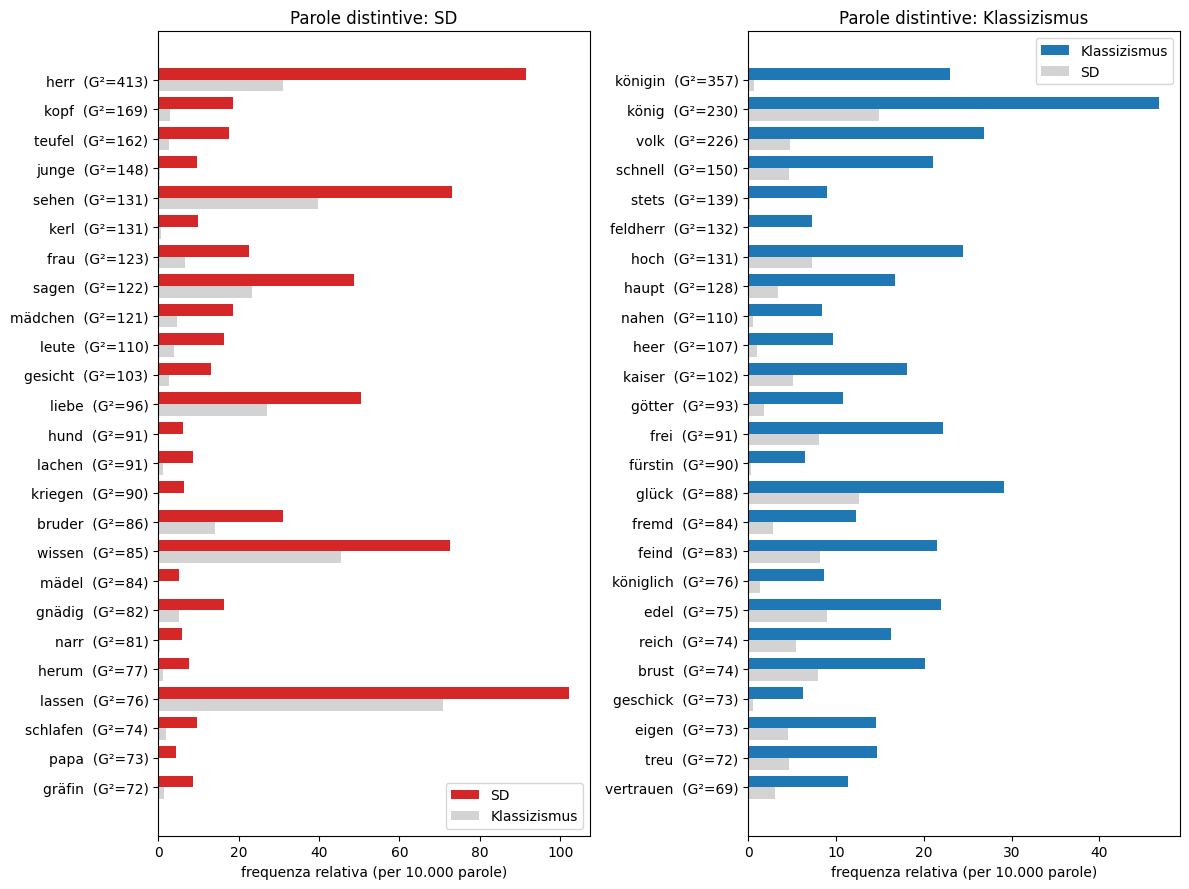

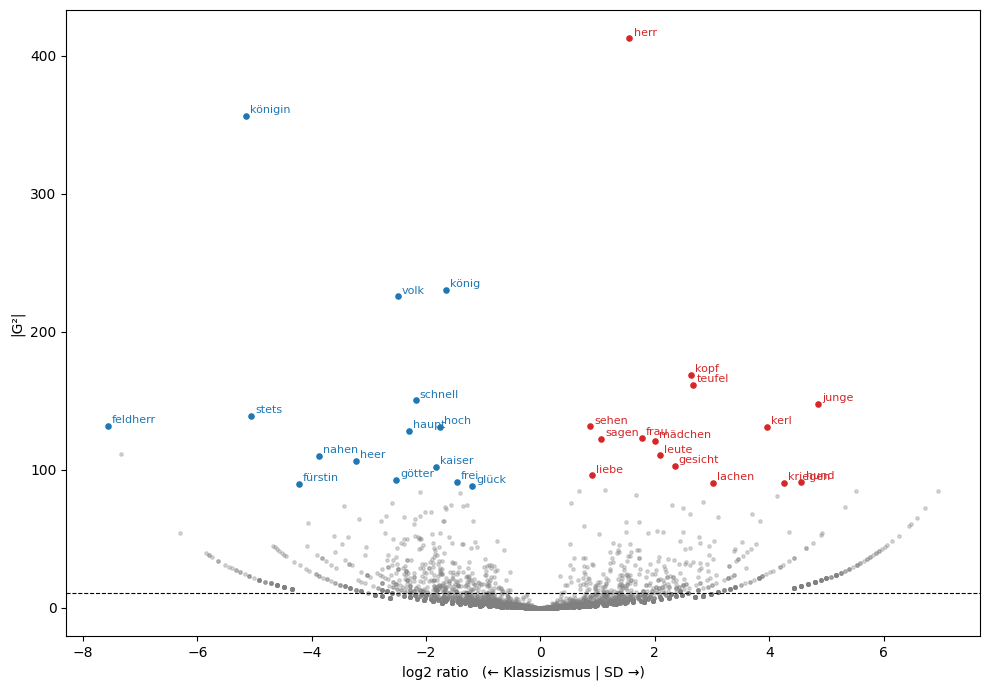

In [16]:
fig, assi = plt.subplots(1, 2, figsize=(12, 9))
for ax, (c, tabella, colore) in zip(assi, [("SD", distintive_SD, "tab:red"), ("Klassizismus", distintive_K, "tab:blue")]):
    altra = "Klassizismus" if c == "SD" else "SD"
    top = tabella.head(25)
    y = np.arange(len(top))[::-1]
    ax.barh(y + 0.2, top[f"f_{c} x10k"], height=0.4, color=colore, label=c)
    ax.barh(y - 0.2, top[f"f_{altra} x10k"], height=0.4, color="lightgray", label=altra)
    ax.set_yticks(y)
    ax.set_yticklabels([f"{w}  (G²={abs(g):.0f})" for w, g in zip(top.index, top["G2"])])
    ax.set_xlabel("frequenza relativa (per 10.000 parole)")
    ax.set_title(f"Parole distintive: {c}")
    ax.legend()
plt.tight_layout()
plt.show()

visibili = freq[freq["totale"] >= MIN_COUNT]
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(visibili["log2_ratio"], visibili["G2"].abs(), s=6, alpha=0.3, color="gray")
for tabella, colore in [(distintive_SD.head(15), "tab:red"), (distintive_K.head(15), "tab:blue")]:
    ax.scatter(tabella["log2_ratio"], tabella["G2"].abs(), s=14, color=colore)
    for w, riga in tabella.iterrows():
        ax.annotate(w, (riga["log2_ratio"], abs(riga["G2"])), fontsize=8, color=colore, xytext=(3, 2), textcoords="offset points")
ax.axhline(10.83, ls="--", lw=0.8, color="black")
ax.set_xlabel("log2 ratio   (← Klassizismus | SD →)")
ax.set_ylabel("|G²|")
plt.tight_layout()
plt.show()

### 6b. Seconda misura: log-odds con prior informativo

G² per le parole molto frequenti anche una differenza piccola dà un G² enorme. Come controllo incrociato usiamo una misura diversa, i **log-odds con prior informativo** (v. Monroe, Colaresi e Quinn, 2008).

Così invece di confrontare le frequenze grezze, si «aggiunge» a ogni parola un po' di conteggi in proporzione alla sua frequenza complessiva (il *prior*).
Le parole rare, con pochi dati, vengono riportate verso zero; le parole frequenti restano quasi com'erano. Il risultato è un punteggio **z**: positivo = SD, negativo = Klassizismus; |z| > 4,8 corrisponde grosso modo alla soglia di Bonferroni. `ALFA0` è la «forza» del prior (500 è un valore usuale).

Se una parola è distintiva per G² **e** per z, la conclusione non dipende dalla misura scelta.

In [17]:
ALFA0 = 500          # forza del prior
Z_SOGLIA = float(np.sqrt(G2_BONF))

def z_log_odds(s, k, alfa0=ALFA0):
    # z-score dei log-odds con prior informativo (>0 = più frequente in SD)
    s, k = np.asarray(s, dtype=float), np.asarray(k, dtype=float)
    n1, n2 = s.sum(), k.sum()
    alfa = alfa0 * (s + k) / (s + k).sum()               # prior proporzionale alla frequenza complessiva
    lo_1 = np.log((s + alfa) / (n1 + alfa0 - s - alfa))
    lo_2 = np.log((k + alfa) / (n2 + alfa0 - k - alfa))
    varianza = 1 / (s + alfa) + 1 / (k + alfa)
    return (lo_1 - lo_2) / np.sqrt(varianza)

freq["z_logodds"] = z_log_odds(freq["conteggio_SD"], freq["conteggio_Klassizismus"])

for c, tab in [("SD", distintive_SD), ("Klassizismus", distintive_K)]:
    segno = 1 if c == "SD" else -1
    top_z = freq[(freq[f"conteggio_{c}"] >= MIN_COUNT) & (freq[f"opere_{c}"] >= MIN_OPERE)]
    top_z = (segno * top_z["z_logodds"]).sort_values(ascending=False).head(len(tab)).index
    comuni = set(tab.index) & set(top_z)
    print(f"{c}: {len(comuni)}/{len(tab)} parole sono in cima per G² e anche per log-odds")
    print("   solo G²:      ", ", ".join(sorted(set(tab.index) - set(top_z))) or "nessuna")
    print("   solo log-odds:", ", ".join(sorted(set(top_z) - set(tab.index))) or "nessuna")

SD: 35/50 parole sono in cima per G² e anche per log-odds
   solo G²:       bekommen, empfindung, familie, frauenzimmer, hofmeister, hund, hübsch, komödie, mama, maul, mädel, nase, papa, verlieben, wetter
   solo log-odds: auge, beten, bitten, gedanke, haar, leib, nacht, nehmen, ritter, sitzen, tot, vater, verzeihen, wein, weinen
Klassizismus: 40/50 parole sono in cima per G² e anche per log-odds
   solo G²:       bund, feldherr, fürstin, gemüt, jungfrau, krieger, rettung, senden, unglückselig, ziemen
   solo log-odds: erscheinen, fest, lösen, retten, scheinen, schmerz, sprechen, wille, wort, zeigen


## 7. Controlli

G² considera il corpus come un unico sacco di parole, ma le parole stanno dentro **opere** (di lunghezze molto diverse) scritte da **autori**. I controlli di questa sezione e della prossima verificano che le parole distintive non dipendano da una singola opera o da un singolo autore.

Prepariamo le parole da controllare (`candidate`) e il segno atteso: +1 se la parola è tipica dello SD, −1 se della Klassizismus.

In [18]:
candidate = list(distintive_SD.index) + list(distintive_K.index)       # le parole da controllare
posizione = freq.index.get_indexer(candidate)                          # dove stanno nelle colonne di X
segno_atteso = np.array([1] * len(distintive_SD) + [-1] * len(distintive_K))   # +1 = SD, -1 = Klassizismus

controlli = freq.loc[candidate, ["G2", "log2_ratio", "z_logodds"]].copy()
controlli.insert(0, "classe", np.where(segno_atteso == 1, "SD", "Klassizismus"))
controlli["G2 > Bonferroni"] = controlli["G2"].abs() > G2_BONF
print(f"{len(candidate)} parole da controllare ({len(distintive_SD)} SD + {len(distintive_K)} Klassizismus)")

100 parole da controllare (50 SD + 50 Klassizismus)


### 7a. Controllo per opera, e pesi uguali per opera

**Test di Mann-Whitney.** Per ogni parola calcoliamo la frequenza **in ciascun dramma** (per 10.000 parole di quel dramma) e confrontiamo le opere SD con le opere Klassizismus. Ogni opera pesa uguale, lunga o corta.
- **r**: grandezza dell'effetto (+1 = tutte le opere SD sopra tutte le Klassizismus; −1 = il contrario; 0 = nessuna differenza).
- **q**: p-value corretto per i confronti multipli (Benjamini-Hochberg).

Una parola **regge per opera** se q < 0,05 e r ha il segno atteso.

**Pesi uguali per opera.** G² somma tutte le parole di una classe: un dramma lungo come *Wallenstein* (circa 19.000 parole) pesa più di uno breve. Qui calcoliamo invece la **media delle frequenze delle singole opere**, in cui ogni opera pesa uguale, e il log₂ ratio tra le due medie. Una parola **concorda a pesi uguali** se la differenza ha il segno atteso e almeno la grandezza `MIN_LOG2`. (Aggiungiamo 0,1 per 10.000 parole alle medie per evitare divisioni per zero.)

In [19]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

da_testare = (freq["totale"] >= MIN_COUNT).to_numpy()
frequenza_opera = X / parole_opera[:, None] * 1e4              # frequenza per 10.000 parole di ogni opera
F_sd, F_k = frequenza_opera[opera_sd][:, da_testare], frequenza_opera[~opera_sd][:, da_testare]
n_opere_sd, n_opere_k = len(F_sd), len(F_k)

U, p = mannwhitneyu(F_sd, F_k, alternative="two-sided", axis=0)
p = np.nan_to_num(p, nan=1.0)
q = multipletests(p, method="fdr_bh")[1]
per_opera = pd.DataFrame({"r_opere": 2 * U / (n_opere_sd * n_opere_k) - 1, "q_opere": q}, index=freq.index[da_testare])

controlli["r_opere"] = per_opera.loc[candidate, "r_opere"]
controlli["q_opere"] = per_opera.loc[candidate, "q_opere"]
controlli["regge per opera"] = (controlli["q_opere"] < 0.05) & (segno_atteso * controlli["r_opere"] > 0)

# pesi uguali per opera: media delle frequenze delle opere di ciascuna classe
media_sd = frequenza_opera[opera_sd].mean(0)[posizione]
media_k = frequenza_opera[~opera_sd].mean(0)[posizione]
controlli["log2 pesi uguali"] = np.log2((media_sd + 0.1) / (media_k + 0.1))
controlli["concorda a pesi uguali"] = segno_atteso * controlli["log2 pesi uguali"] >= MIN_LOG2

for c in classi:
    t = controlli[controlli["classe"] == c]
    print(f"{c}: {t['G2 > Bonferroni'].sum()}/{len(t)} sopra Bonferroni, {t['regge per opera'].sum()}/{len(t)} reggono per opera, "
          f"{t['concorda a pesi uguali'].sum()}/{len(t)} concordano a pesi uguali")
    print("   NON reggono per opera:", ", ".join(t.index[~t["regge per opera"]]) or "nessuna")
    print("   NON concordano a pesi uguali:", ", ".join(t.index[~t["concorda a pesi uguali"]]) or "nessuna")

SD: 50/50 sopra Bonferroni, 42/50 reggono per opera, 50/50 concordano a pesi uguali
   NON reggono per opera: frau, liebe, bruder, papa, gräfin, mama, hauptmann, hofmeister
   NON concordano a pesi uguali: nessuna
Klassizismus: 50/50 sopra Bonferroni, 43/50 reggono per opera, 50/50 concordano a pesi uguali
   NON reggono per opera: königin, könig, kaiser, götter, glück, land, jungfrau
   NON concordano a pesi uguali: nessuna


**Grafico per opera.** Ogni punto è un'opera, la linea nera è la mediana. Una parola solida ha le due nuvole separate; una fragile ha quasi tutti i punti a zero e pochi valori molto alti.

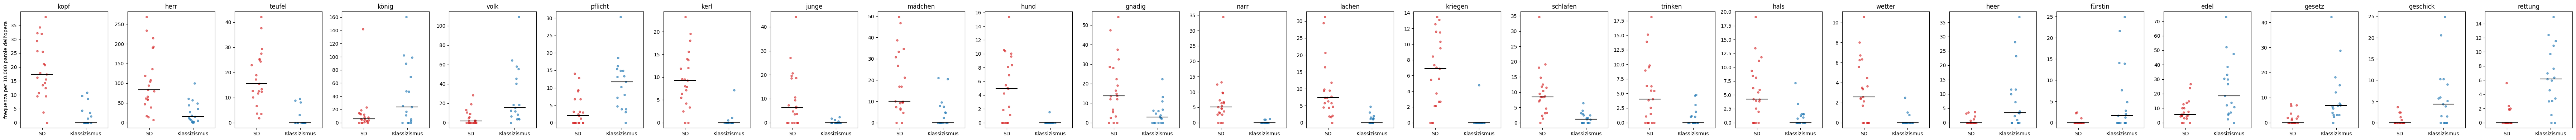

In [20]:
def mostra_per_opera(parole):
    parole = [w for w in parole if w in freq.index and da_testare[freq.index.get_loc(w)]]
    if not parole:
        print("Nessuna parola con abbastanza occorrenze")
        return
    fig, assi = plt.subplots(1, len(parole), figsize=(3 * len(parole), 4), squeeze=False)
    rng_g = np.random.default_rng(0)
    for ax, w in zip(assi[0], parole):
        valori_w = frequenza_opera[:, freq.index.get_loc(w)]
        for i, (maschera, colore) in enumerate([(opera_sd, "tab:red"), (~opera_sd, "tab:blue")]):
            v = valori_w[maschera]
            ax.scatter(i + rng_g.uniform(-0.12, 0.12, len(v)), v, s=14, alpha=0.6, color=colore)
            ax.hlines(np.median(v), i - 0.25, i + 0.25, color="black")
        ax.set_xticks([0, 1]); ax.set_xticklabels(["SD", "Klassizismus"]); ax.set_xlim(-0.5, 1.5)
        ax.set_title(w)
    assi[0][0].set_ylabel("frequenza per 10.000 parole dell'opera")
    plt.tight_layout()
    plt.show()

mostra_per_opera(["kopf", "herr", "teufel", "könig", "volk", "pflicht", "kerl", "junge", "mädchen", "hund", "gnädig", "narr", "lachen", "kriegen", "schlafen", "trinken", "hals", "wetter", "heer", "fürstin", "edel", "gesetz", "geschick", "rettung"])

### 7b. Controllo a parità di autore

Goethe e Schiller compaiono **in entrambe le classi**: confrontando il Goethe SD con il Goethe della Klassizismus (e lo stesso per Schiller) l'autore resta lo stesso e cambia solo il periodo. Una parola tipica della corrente deve andare nella stessa direzione anche dentro ciascun autore. Il segno è giudicato solo se l'autore usa la parola almeno `MIN_OCC_AUTORE` volte in tutto.

L'autore è ricavato dal nome del file (la parte prima del primo trattino); i casi particolari (*Schlegel*, *Maler Müller*) sono sistemati a mano in `AUTORE_MANUALE`.

In [21]:
MIN_OCC_AUTORE = 5

AUTORE_MANUALE = {"schlegel-jon": "schlegel-aw", "schlegel-alarcos": "schlegel-f",
                  "maler-mueller-golo-und-genovefa": "maler-mueller",
                  "maler-mueller-fausts-leben-dramatisiert": "maler-mueller"}
autore_di = {o: AUTORE_MANUALE.get(o, o.split("-")[0]) for o in opere}
autore_arr = np.array([autore_di[o] for o in opere])

classi_dell_autore = {}
for o in opere:
    classi_dell_autore.setdefault(autore_di[o], set()).add(classe_di[o])
autori_condivisi = sorted(a for a, cl in classi_dell_autore.items() if len(cl) == 2)
print("Autori presenti in entrambe le classi:", ", ".join(autori_condivisi))
print("Opere per autore e classe:")
print(pd.crosstab(pd.Series(autore_arr, name="autore"), pd.Series(np.where(opera_sd, "SD", "Klassizismus"), name="classe")).to_string())

segni_ok = pd.DataFrame(index=candidate)
for aut in autori_condivisi:
    idx_sd = [i for i, o in enumerate(opere) if autore_di[o] == aut and classe_di[o] == "SD"]
    idx_k = [i for i, o in enumerate(opere) if autore_di[o] == aut and classe_di[o] == "Klassizismus"]
    cnt_sd, cnt_k = X[idx_sd].sum(0)[posizione], X[idx_k].sum(0)[posizione]
    tok_sd, tok_k = X[idx_sd].sum(), X[idx_k].sum()
    log2_autore = np.log2(((cnt_sd + 0.5) / tok_sd) / ((cnt_k + 0.5) / tok_k))
    giudicabile = (cnt_sd + cnt_k) >= MIN_OCC_AUTORE
    controlli[f"log2 {aut}"] = np.where(giudicabile, log2_autore, np.nan)
    segni_ok[aut] = (np.sign(log2_autore) * segno_atteso > 0) | ~giudicabile

controlli["concorda in ogni autore"] = segni_ok.all(axis=1)
for c in classi:
    t = controlli[controlli["classe"] == c]
    print(f"\n{c}: {t['concorda in ogni autore'].sum()}/{len(t)} concordano dentro {' e '.join(autori_condivisi)}")
    print("   si invertono in almeno un autore:", ", ".join(t.index[~t["concorda in ogni autore"]]) or "nessuna")

Autori presenti in entrambe le classi: goethe, schiller
Opere per autore e classe:
classe         Klassizismus  SD
autore                         
collin                    2   0
goethe                    5   4
klinger                   0   5
leisewitz                 0   1
lenz                      0   5
maler-mueller             0   1
schiller                  6   3
schlegel-aw               1   0
schlegel-f                1   0
seume                     1   0
wagner                    0   2
wolzogen                  1   0

SD: 47/50 concordano dentro goethe e schiller
   si invertono in almeno un autore: wissen, brav, gewiß

Klassizismus: 44/50 concordano dentro goethe e schiller
   si invertono in almeno un autore: kaiser, feind, reich, vaterland, land, sieg


## 8. Controlli di robustezza

I controlli di base dicono che le parole distintive non dipendono da *una* opera. Questa sezione chiede se dipendono da **come è fatto il corpus** (quali autori ci sono, quanto pesano) e da **come sono scelti i parametri**.

### 8a. Quanto distintive sono le parole di una divisione casuale?

Dividendo i drammi in due gruppi qualsiasi, G² trova **sempre** qualche parola distintiva. Il test di permutazione costruisce il termine di paragone: si rimescolano le etichette SD/Klassizismus e si contano le parole distintive della divisione casuale (stessi filtri della sezione 6, con Bonferroni). Il p-value è la quota di divisioni casuali che producono almeno tante parole quante la divisione reale. Con `N_PERM` = 1000 il valore più basso possibile è 1/1001 ≈ 0,001.

Due modalità:

- **opere**: si rimescolano le etichette tra singole opere;
- **autori** (8b): si rimescolano blocchi **autore × classe**. Le opere dello stesso autore nello stesso periodo restano insieme.

In [22]:
rng = np.random.default_rng(42)       # il seme rende il risultato ripetibile

def conta(in_sd):
    ok_sd, ok_k, _, _ = parole_distintive(X, in_sd, ~in_sd)
    return int(ok_sd.sum() + ok_k.sum())

reali = conta(opera_sd)
print(f"Divisione reale SD/Klassizismus: {reali} parole distintive (con Bonferroni)")

casuali_opere = np.array([conta(rng.permutation(opera_sd)) for _ in range(N_PERM)])
p_opere = (np.sum(casuali_opere >= reali) + 1) / (N_PERM + 1)
print(f"[opere]  divisioni casuali: media {casuali_opere.mean():.0f}, 95° percentile {np.percentile(casuali_opere, 95):.0f}, "
      f"massimo {casuali_opere.max()}  ->  p = {p_opere:.4f}")

Divisione reale SD/Klassizismus: 369 parole distintive (con Bonferroni)
[opere]  divisioni casuali: media 42, 95° percentile 64, massimo 116  ->  p = 0.0010


### 8b. Permutazione per blocchi autore × classe

Ogni blocco è un insieme di opere dello stesso autore nella stessa classe (per esempio «klinger|SD», «goethe|Klassizismus»). Si rimescolano le etichette dei **blocchi**, mantenendo il numero di blocchi SD e Klassizismus: lo stile personale di un autore non può così gonfiare il risultato. Il test è più severo del precedente.

14 blocchi autore × classe (7 SD, 7 Klassizismus)
[autori] divisioni casuali: media 96, 95° percentile 195, massimo 369  ->  p = 0.0020

Divisione reale: 369 parole distintive.


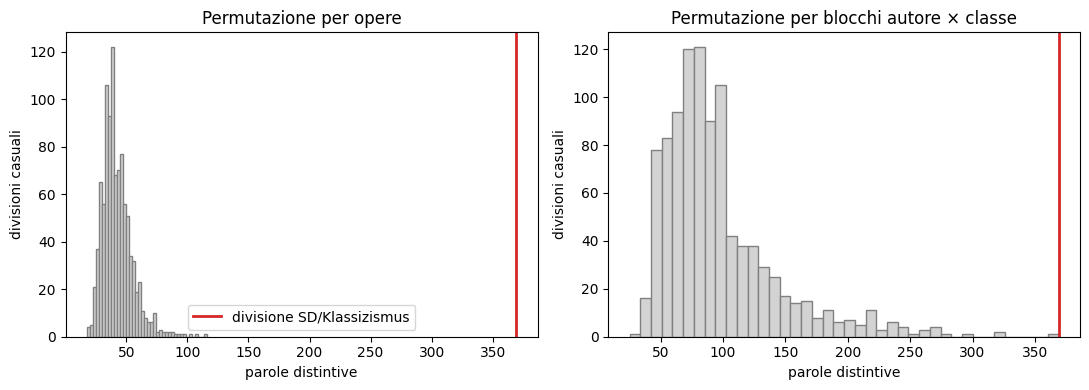

In [23]:
blocco = np.array([f"{autore_di[o]}|{classe_di[o]}" for o in opere])
blocchi = np.unique(blocco)
blocchi_sd = np.array([bl.endswith("|SD") for bl in blocchi])
print(f"{len(blocchi)} blocchi autore × classe ({blocchi_sd.sum()} SD, {(~blocchi_sd).sum()} Klassizismus)")

def rimescola_blocchi():
    etichette = dict(zip(blocchi, rng.permutation(blocchi_sd)))
    return np.array([etichette[bl] for bl in blocco])

casuali_autori = np.array([conta(rimescola_blocchi()) for _ in range(N_PERM)])
p_autori = (np.sum(casuali_autori >= reali) + 1) / (N_PERM + 1)
print(f"[autori] divisioni casuali: media {casuali_autori.mean():.0f}, 95° percentile {np.percentile(casuali_autori, 95):.0f}, "
      f"massimo {casuali_autori.max()}  ->  p = {p_autori:.4f}")
print(f"\nDivisione reale: {reali} parole distintive.")

fig, assi = plt.subplots(1, 2, figsize=(11, 4))
for ax, (nome, dati) in zip(assi, [("opere", casuali_opere), ("blocchi autore × classe", casuali_autori)]):
    ax.hist(dati, bins=40, color="lightgray", edgecolor="gray")
    ax.axvline(reali, color="tab:red", lw=2, label="divisione SD/Klassizismus")
    ax.set_title(f"Permutazione per {nome}")
    ax.set_xlabel("parole distintive"); ax.set_ylabel("divisioni casuali")
assi[0].legend()
plt.tight_layout()
plt.show()

### 8c. Leave-one-author-out: togliere un autore alla volta

Ricalcoliamo le parole distintive togliendo **tutte le opere di un autore** (in entrambe le classi) e ripetiamo per ogni autore. Una parola è **stabile** se resta distintiva qualunque autore venga tolto. Per le parole che cadono, la colonna `cade senza` dice quale autore (o autori) la regge.

In [24]:
def candidate_ancora_distintive(maschera_opere, **parametri):
    # per ogni parola da controllare: è ancora distintiva (nella sua classe) usando solo le opere della maschera?
    ok_sd, ok_k, _, _ = parole_distintive(X, opera_sd & maschera_opere, ~opera_sd & maschera_opere, **parametri)
    return np.where(segno_atteso > 0, ok_sd[posizione], ok_k[posizione])

tutti_gli_autori = sorted(set(autore_arr))
LOAO = pd.DataFrame({aut: candidate_ancora_distintive(autore_arr != aut) for aut in tutti_gli_autori}, index=candidate)
ok_con_tutti = pd.Series(candidate_ancora_distintive(np.ones(len(opere), bool)), index=candidate)

# una parola è stabile se è distintiva con tutti gli autori E resta distintiva togliendone uno qualunque
controlli["stabile senza ogni autore"] = ok_con_tutti & LOAO.all(axis=1)
controlli["cade senza"] = [", ".join(LOAO.columns[~LOAO.loc[w]]) if ok_con_tutti[w]
                           else "(già non distintiva con tutti gli autori)" for w in candidate]

for c in classi:
    t = controlli[controlli["classe"] == c]
    print(f"{c}: {t['stabile senza ogni autore'].sum()}/{len(t)} stabili togliendo un autore alla volta")
    cadono = t[~t["stabile senza ogni autore"]]
    print("   instabili:", "; ".join(f"{w} (cade senza {r})" for w, r in cadono["cade senza"].items()) or "nessuna")

# quanto pesa ciascun autore: quante delle parole da controllare cadono se lo togli
print("\nParole che cadono togliendo ciascun autore:")
print((~LOAO)[ok_con_tutti].sum().sort_values(ascending=False).to_string())

SD: 40/50 stabili togliendo un autore alla volta
   instabili: liebe (cade senza klinger); lassen (cade senza klinger, lenz, seume); papa (cade senza lenz); gräfin (cade senza maler-mueller); hauptmann (cade senza schiller); schreiben (cade senza lenz); gewiß (cade senza schiller); hofmeister (cade senza lenz); küssen (cade senza klinger); bekommen (cade senza lenz)
Klassizismus: 40/50 stabili togliendo un autore alla volta
   instabili: königin (cade senza schiller); kaiser (cade senza schiller); feind (cade senza schiller); reich (cade senza schiller); eigen (cade senza schiller); treu (cade senza schiller); land (cade senza schiller); jungfrau (cade senza schiller); unglückselig (cade senza schiller); gemüt (cade senza goethe)

Parole che cadono togliendo ciascun autore:
schiller         11
lenz              5
klinger           3
goethe            1
maler-mueller     1
seume             1
leisewitz         0
collin            0
schlegel-aw       0
schlegel-f        0
wagner         

### 8d. Composizione del corpus: tre sottocampioni

Tre prove, ciascuna con il suo risultato per parola («la parola è ancora distintiva?»):

1. **Senza gli autori minori della Klassizismus** (`AUTORI_MINORI_KLASSIK`: Collin, i due Schlegel, Seume, Wolzogen): restano Goethe e Schiller. Sono opere originali di autori meno noti, con temi spesso storici o mitologici; vedere se il risultato cambia toglie questo possibile peso.
2. **Al massimo 3 opere per autore e classe**, estratte a caso `N_SOTTOCAMPIONI` volte: nello SD, Klinger e Lenz hanno 5 opere ciascuno e peserebbero troppo. Per ogni parola si riporta la **quota di estrazioni** in cui resta distintiva.
3. **Senza le opere sotto 2.000 parole**: le brevi (*Satyros*, *Pandaemonium germanicum*, *Der Engländer*) hanno frequenze meno affidabili.

Una parola è **stabile** in una prova se resta distintiva in almeno `SOGLIA_STABILITA` delle estrazioni (nelle prove 1 e 3 c'è una sola estrazione: deve restare distintiva).

In [25]:
# 1. senza autori minori della Klassizismus
maschera_1 = ~np.array([(autore_di[o] in AUTORI_MINORI_KLASSIK) and classe_di[o] == "Klassizismus" for o in opere])
print(f"1. senza autori minori Klassizismus: {maschera_1.sum()} opere ({(maschera_1 & opera_sd).sum()} SD, {(maschera_1 & ~opera_sd).sum()} Klassizismus)")
controlli["stabile senza autori minori"] = candidate_ancora_distintive(maschera_1)

# 2. al massimo 3 opere per autore e classe, estratte a caso
indici_blocco = {bl: np.where(blocco == bl)[0] for bl in blocchi}
quota_max3 = np.zeros(len(candidate))
for _ in range(N_SOTTOCAMPIONI):
    scelte = np.concatenate([rng.choice(idx, size=min(3, len(idx)), replace=False) for idx in indici_blocco.values()])
    m = np.zeros(len(opere), bool)
    m[scelte] = True
    quota_max3 += candidate_ancora_distintive(m)
controlli["quota con max 3 opere per autore"] = quota_max3 / N_SOTTOCAMPIONI
controlli["stabile con max 3 opere per autore"] = controlli["quota con max 3 opere per autore"] >= SOGLIA_STABILITA
print(f"2. al massimo 3 opere per autore e classe: {N_SOTTOCAMPIONI} estrazioni")

# 3. senza opere sotto 2.000 parole
maschera_3 = parole_opera >= 2000
print(f"3. senza opere sotto 2.000 parole: escluse {', '.join(o for o, m in zip(opere, maschera_3) if not m) or 'nessuna'}")
controlli["stabile senza opere brevi"] = candidate_ancora_distintive(maschera_3)

for col in ["stabile senza autori minori", "stabile con max 3 opere per autore", "stabile senza opere brevi"]:
    print(f"\n{col}:")
    for c in classi:
        t = controlli[controlli["classe"] == c]
        print(f"   {c}: {t[col].sum()}/{len(t)}. Non stabili: {', '.join(t.index[~t[col]]) or 'nessuna'}")

1. senza autori minori Klassizismus: 32 opere (21 SD, 11 Klassizismus)
2. al massimo 3 opere per autore e classe: 200 estrazioni
3. senza opere sotto 2.000 parole: escluse goethe-satyros, lenz-der-englaender, lenz-pandaemonium-germanicum

stabile senza autori minori:
   SD: 49/50. Non stabili: lassen
   Klassizismus: 45/50. Non stabili: götter, vaterland, krieger, sieg, einst

stabile con max 3 opere per autore:
   SD: 46/50. Non stabili: lassen, papa, hofmeister, küssen
   Klassizismus: 46/50. Non stabili: kaiser, land, jungfrau, unglückselig

stabile senza opere brevi:
   SD: 50/50. Non stabili: nessuna
   Klassizismus: 50/50. Non stabili: nessuna


### 8e. Robustezza ai parametri

I filtri `MIN_COUNT`, `MIN_OPERE` e `MIN_LOG2` sono scelte nostre. Ripetiamo il calcolo con **18 combinazioni** (`MIN_COUNT` = 5, 10, 20; `MIN_OPERE` = 3, 5, 8; `MIN_LOG2` = 0,5 e 0,75) e contiamo in quante una parola resta distintiva. Una parola è **stabile ai parametri** se resta distintiva in almeno `SOGLIA_STABILITA` delle combinazioni. Chi cade qui ha di solito una differenza piccola (log₂ ratio vicino alla soglia) o è concentrata in poche opere.

In [26]:
from itertools import product
griglia = list(product([5, 10, 20], [3, 5, 8], [0.5, 0.75]))
tutte = np.ones(len(opere), bool)
resta = np.zeros(len(candidate))
for mc, mo, ml in griglia:
    resta += candidate_ancora_distintive(tutte, min_count=mc, min_opere=mo, min_log2=ml)
controlli["quota nei parametri"] = resta / len(griglia)
controlli["stabile ai parametri"] = controlli["quota nei parametri"] >= SOGLIA_STABILITA

for c in classi:
    t = controlli[controlli["classe"] == c]
    print(f"{c}: {t['stabile ai parametri'].sum()}/{len(t)} stabili nelle {len(griglia)} combinazioni di parametri")
    print("   non stabili:", ", ".join(f"{w} ({q:.2f})" for w, q in t.loc[~t['stabile ai parametri'], 'quota nei parametri'].items()) or "nessuna")

SD: 43/50 stabili nelle 18 combinazioni di parametri
   non stabili: wissen (0.50), lassen (0.50), papa (0.33), gräfin (0.67), mama (0.67), hauptmann (0.67), hofmeister (0.67)
Klassizismus: 48/50 stabili nelle 18 combinazioni di parametri
   non stabili: feldherr (0.67), kaiser (0.33)


## 9. Modello spaCy più grande: le liste cambiano?

Il modello piccolo (`de_core_news_sm`) è addestrato soprattutto su tedesco moderno e sbaglia più spesso sui testi del Settecento (lemmi, parti del discorso). Ripetiamo la pipeline con un modello più grande e vediamo **quali parole distintive restano le stesse**. Le parole che compaiono con entrambi i modelli sono meno a rischio di essere un errore del lemmatizzatore.

La funzione `elabora_corpus` è la stessa: cambia solo il modello. Qui raccogliamo anche i vettori delle parole, che serviranno ai campi semantici (sezione 10). Con `CONFRONTA_MODELLO = False` la sezione viene saltata.

In [27]:
risultato_conf = None
if CONFRONTA_MODELLO:
    if importlib.util.find_spec(MODELLO_CONFRONTO) is None:
        subprocess.run([sys.executable, "-m", "spacy", "download", MODELLO_CONFRONTO], check=True)
    risultato_conf = elabora_corpus(MODELLO_CONFRONTO, raccogli_vettori=True)
else:
    print("Confronto tra modelli saltato (CONFRONTA_MODELLO = False)")

--- Lemmatizzazione con de_core_news_lg ---
[  1/40] SD       goethe-clavigo                                            4,294 parole
[  2/40] SD       goethe-faust-in-urspruenglicher-gestalt                   4,058 parole
[  3/40] SD       goethe-goetz-von-berlichingen-mit-der-eisernen-hand       8,528 parole
[  4/40] SD       goethe-satyros                                            1,062 parole
[  5/40] SD       klinger-das-leidende-weib                                 4,750 parole
[  6/40] SD       klinger-die-neue-arria                                    7,479 parole
[  7/40] SD       klinger-die-zwillinge                                     5,522 parole
[  8/40] SD       klinger-simsone-grisaldo                                  8,324 parole
[  9/40] SD       klinger-sturm-und-drang                                   5,200 parole
[ 10/40] SD       leisewitz-der-besuch-um-mitternacht                         132 parole
[ 11/40] SD       leisewitz-die-pfandung                          

In [28]:
if risultato_conf is not None:
    X_c, vocab_c, opere_c = matrice(risultato_conf["conteggi"])
    sd_c = np.array([classe_di[o] == "SD" for o in opere_c])
    pres_c = (X_c > 0).astype(np.int64)
    ok_sd_c, ok_k_c, _, _ = parole_distintive(X_c, sd_c, ~sd_c, Xpres=pres_c)
    insieme_conf = {"SD": set(vocab_c[ok_sd_c]), "Klassizismus": set(vocab_c[ok_k_c])}

    # liste complete (con Bonferroni) del modello principale
    ok_sd_p, ok_k_p, _, _ = parole_distintive(X, opera_sd, ~opera_sd)
    insieme_princ = {"SD": set(freq.index[ok_sd_p]), "Klassizismus": set(freq.index[ok_k_p])}
    for c in classi:
        inter = insieme_princ[c] & insieme_conf[c]
        unione = insieme_princ[c] | insieme_conf[c]
        print(f"{c}: {len(insieme_princ[c])} parole distintive con {MODELLO}, {len(insieme_conf[c])} con {MODELLO_CONFRONTO}; "
              f"in comune {len(inter)} (Jaccard {len(inter) / len(unione):.2f})")

    controlli["presente anche con il modello grande"] = [
        w in insieme_conf["SD" if s > 0 else "Klassizismus"] for w, s in zip(candidate, segno_atteso)]
    for c in classi:
        t = controlli[controlli["classe"] == c]
        print(f"\n{c}: {t['presente anche con il modello grande'].sum()}/{len(t)} delle parole controllate compaiono anche con il modello grande")
        print("   assenti:", ", ".join(t.index[~t["presente anche con il modello grande"]]) or "nessuna")
    print("\nParole distintive con il modello grande che il piccolo non vede (prime 25 per classe, per frequenza):")
    for c in classi:
        nuove = sorted(insieme_conf[c] - insieme_princ[c], key=lambda w: -X_c[:, vocab_c.get_loc(w)].sum())
        print(f"   {c}:", ", ".join(nuove[:25]) or "nessuna")

SD: 175 parole distintive con de_core_news_sm, 178 con de_core_news_lg; in comune 153 (Jaccard 0.77)
Klassizismus: 194 parole distintive con de_core_news_sm, 205 con de_core_news_lg; in comune 184 (Jaccard 0.86)

SD: 49/50 delle parole controllate compaiono anche con il modello grande
   assenti: lassen

Klassizismus: 50/50 delle parole controllate compaiono anche con il modello grande
   assenti: nessuna

Parole distintive con il modello grande che il piccolo non vede (prime 25 per classe, per frequenza):
   SD: himmel, gut, träne, gehn, komm, verstehen, siehst, degen, hinaus, henker, mahl, hörst, toll, kugel, angenehm, hinunter, schweig, baron, kerls, heiraten, gehirn, küßen, pulver, brutus, honett
   Klassizismus: führen, geschehen, wagen, ists, wenden, geheimnis, öffnen, ruf, trennen, eignen, flehen, gehorchen, frech, pfand, fesseln, pfad, schmach, entfliehen, roh, grieche, innerstes


## 10. Campi semantici e posizione dei drammi

### 10a. Raggruppare le parole distintive per significato

Qui raggruppiamo le parole distintive in **campi semantici** in modo automatico:

1. di ogni parola distintiva si prende il **vettore** del modello grande (un elenco di 300 numeri che codifica il significato: parole simili hanno vettori simili);
2. l'algoritmo **K-means** raggruppa le parole in `N_CAMPI` gruppi di vettori vicini;
3. per ogni gruppo si stampano le parole e si misura **quanto pesa nei drammi SD e nei drammi Klassizismus** (per 10.000 parole), con il test di Mann-Whitney sulle opere.

I gruppi sono costruiti sulle sole parole distintive, quindi tendono a separarsi per corrente; a noi interessa vedere **quali temi** compaiono e se ci sono gruppi misti. **Dare il nome ai campi spetta a te**: guarda le parole di ciascuno. I campi dipendono dal numero scelto: prova anche `N_CAMPI` = 5 o 12.

Per avere abbastanza parole si usano tutte le parole distintive della sezione 6 fino a un massimo di `N_PAROLE_CAMPI`.

In [29]:
N_PAROLE_CAMPI = 300       # massimo di parole distintive da raggruppare

if risultato_conf is None or not risultato_conf["vettori"]:
    print("Vettori non disponibili: sezione saltata (serve CONFRONTA_MODELLO = True con un modello con vettori)")
    campo_di = {}
else:
    from sklearn.cluster import KMeans
    ok_sd_p, ok_k_p, g_p, _ = parole_distintive(X, opera_sd, ~opera_sd)
    scelte = np.where(ok_sd_p | ok_k_p)[0]
    scelte = scelte[np.argsort(-np.abs(g_p[scelte]))][:N_PAROLE_CAMPI]
    parole_campi = [freq.index[i] for i in scelte if freq.index[i] in risultato_conf["vettori"]]
    V = np.array([risultato_conf["vettori"][w] for w in parole_campi])
    V = V / np.linalg.norm(V, axis=1, keepdims=True)                 # vettori di lunghezza 1
    etichette = KMeans(n_clusters=N_CAMPI, n_init=10, random_state=0).fit_predict(V)
    campo_di = dict(zip(parole_campi, etichette))
    print(f"{len(parole_campi)} parole raggruppate in {N_CAMPI} campi\n")

    righe = []
    F_campi = np.zeros((len(opere), N_CAMPI))
    for c in range(N_CAMPI):
        membri = [w for w in parole_campi if campo_di[w] == c]
        idx = freq.index.get_indexer(membri)
        F_campi[:, c] = X[:, idx].sum(1) / parole_opera * 1e4        # peso del campo in ogni opera
        n_sd_w = sum(freq.loc[w, "G2"] > 0 for w in membri)
        U_c, p_c = mannwhitneyu(F_campi[opera_sd, c], F_campi[~opera_sd, c], alternative="two-sided")
        righe.append({"campo": c, "parole SD": n_sd_w, "parole Klassizismus": len(membri) - n_sd_w,
                      "x10k SD (mediana)": np.median(F_campi[opera_sd, c]),
                      "x10k Klassizismus (mediana)": np.median(F_campi[~opera_sd, c]),
                      "r_opere": 2 * U_c / (opera_sd.sum() * (~opera_sd).sum()) - 1, "p": p_c})
        ordinati = sorted(membri, key=lambda w: -abs(freq.loc[w, "G2"]))
        print(f"CAMPO {c}  ({n_sd_w} SD, {len(membri) - n_sd_w} Klassizismus)")
        print("   ", ", ".join(f"{w}{'*' if freq.loc[w, 'G2'] > 0 else ''}" for w in ordinati[:25]))
    print("\n(* = parola distintiva dello SD; senza asterisco = Klassizismus)\n")
    campi_tab = pd.DataFrame(righe).set_index("campo")
    campi_tab["q"] = multipletests(campi_tab["p"], method="fdr_bh")[1]
    print(campi_tab.round(3).to_string())

295 parole raggruppate in 8 campi

CAMPO 0  (9 SD, 40 Klassizismus)
    stets, hoch, frei, königlich, vertrauen, empfindung*, schweigen, streng, land, pflicht, freilich*, rettung, gesetz, bund, fest, wille, gleich, beschützen, ergreifen, zweig, vereinen, bedürfen, bürger, waffe, gedanke*
CAMPO 1  (33 SD, 3 Klassizismus)
    kopf*, kerl*, leute*, gesicht*, hund*, lachen*, mädel*, schlafen*, brust, papa*, mama*, nase*, hals*, küssen*, zart, trinken*, maul*, schmerz, tanzen*, wein*, haar*, essen*, weinen*, abend*, auge*
CAMPO 2  (3 SD, 25 Klassizismus)
    königin, könig, volk, feldherr, haupt, heer, kaiser, feind, reich, vaterland, gunst, krieger, sieg, einst, ritter*, schar, stamm, bestie*, herrscher, fürst, thron, ruhm, kampf, schlacht, schurk*
CAMPO 3  (16 SD, 13 Klassizismus)
    schnell, glück, herum*, geschick, hübsch*, teuer, rasch, neu, lager, wetter*, stück*, spaß*, glas*, ball*, geld*, hinein*, drüber*, flut, monat*, unmut, halt*, glanz, ding*, schwer, geschwind*
CAMPO 4  (24 S

### 10b. Quanto pesa ogni campo in ogni dramma

Il grafico è una mappa: ogni riga è un dramma (in alto lo SD, in basso la Klassizismus), ogni colonna un campo. Il colore dice se il campo è **più o meno presente della media** (in rosso: più presente; in blu: meno). Si vede a colpo d'occhio quali drammi si comportano da «tipici» della loro classe e quali «di confine».

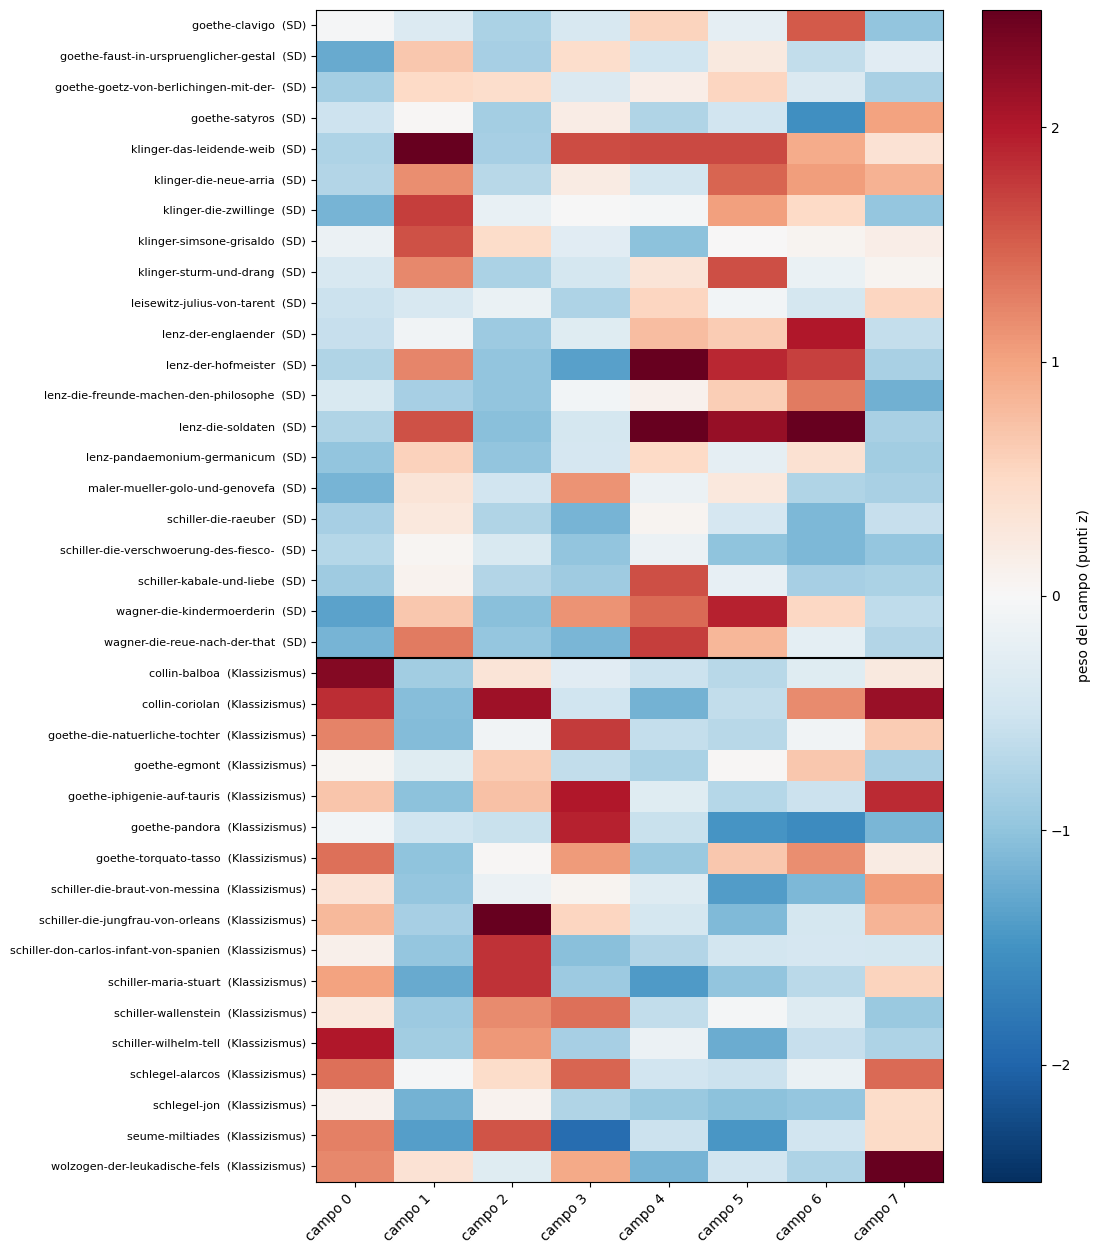

In [30]:
if campo_di:
    Z = (F_campi - F_campi.mean(0)) / F_campi.std(0)
    ordine = np.lexsort((np.array(opere), ~opera_sd))      # prima SD, poi Klassizismus; in ordine alfabetico
    fig, ax = plt.subplots(figsize=(0.9 * N_CAMPI + 4, 0.28 * len(opere) + 2))
    im = ax.imshow(Z[ordine], cmap="RdBu_r", vmin=-2.5, vmax=2.5, aspect="auto")
    ax.set_xticks(range(N_CAMPI)); ax.set_xticklabels([f"campo {c}" for c in range(N_CAMPI)], rotation=45, ha="right")
    ax.set_yticks(range(len(opere)))
    ax.set_yticklabels([f"{opere[i][:38]}  ({classe_di[opere[i]]})" for i in ordine], fontsize=8)
    n_sd_tot = opera_sd.sum()
    ax.axhline(n_sd_tot - 0.5, color="black", lw=1.5)
    plt.colorbar(im, label="peso del campo (punti z)")
    plt.tight_layout()
    plt.show()

### 10c. Posizione di ogni dramma sull'asse lessicale

Ogni dramma riceve un **punteggio lessicale**: la somma, parola per parola, della sua frequenza moltiplicata per il log₂ ratio della parola (positivo = SD, negativo = Klassizismus). Usiamo solo parole con G² sopra Bonferroni. Per non favorire l'opera che stiamo valutando, **il lessico è ricalcolato senza di lei** (stessa idea del *leave-one-out*).

Il punteggio viene poi ridotto a una scala semplice: **0 = come la media dei drammi Klassizismus, 1 = come la media dei drammi SD**. I drammi lontani dalla loro classe sono i «di confine».

Posizione sull'asse: 0 = come la media dei drammi Klassizismus, 1 = come la media dei drammi SD
              count  mean   std   min   max
classe                                     
Klassizismus   17.0  -0.0  0.22 -0.33  0.51
SD             21.0   1.0  0.30  0.55  1.68

Drammi SD più vicini alla Klassizismus: goethe-satyros (0.55), leisewitz-julius-von-tarent (0.74), klinger-simsone-grisaldo (0.76), schiller-die-verschwoerung-des-fiesco-zu-genua (0.76)
Drammi Klassizismus più vicini allo SD: goethe-egmont (0.51), schiller-don-carlos-infant-von-spanien (0.34), schiller-wallenstein (0.29), schiller-wilhelm-tell (0.13)


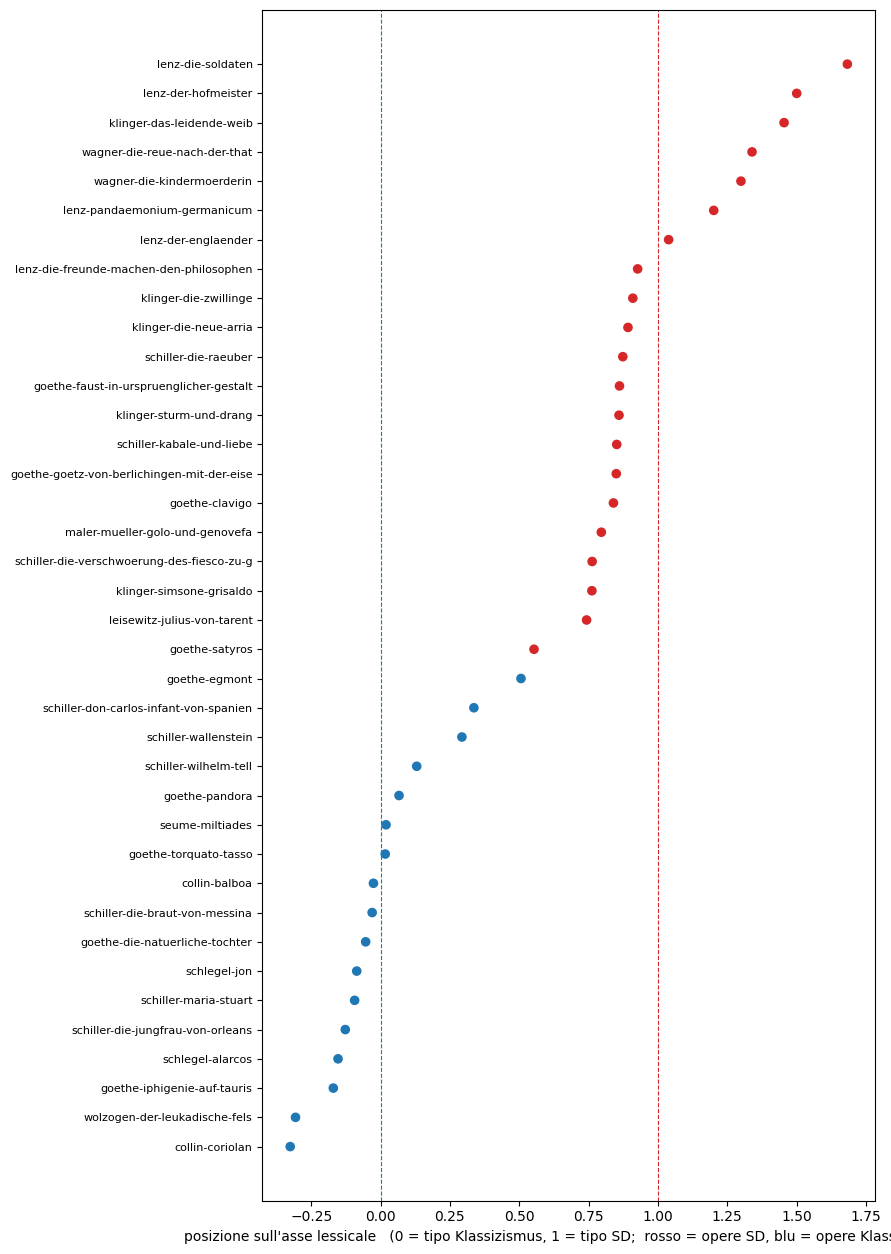

In [31]:
Xrel = X / parole_opera[:, None]
punteggio = np.zeros(len(opere))
for i in range(len(opere)):
    resto = np.arange(len(opere)) != i                       # tutte le opere tranne la i-esima
    s, k = X[resto & opera_sd].sum(0), X[resto & ~opera_sd].sum(0)
    g = g2(s, k, s.sum(), k.sum())
    l2 = np.log2(((s + 0.5) / s.sum()) / ((k + 0.5) / k.sum()))
    pesi = np.where(((s + k) >= MIN_COUNT) & (np.abs(g) > G2_BONF), l2, 0.0)
    punteggio[i] = Xrel[i] @ pesi

m_sd, m_k = punteggio[opera_sd].mean(), punteggio[~opera_sd].mean()
asse = pd.DataFrame({"classe": [classe_di[o] for o in opere], "autore": autore_arr, "parole": parole_opera,
                     "posizione": (punteggio - m_k) / (m_sd - m_k)}, index=opere)
print("Posizione sull'asse: 0 = come la media dei drammi Klassizismus, 1 = come la media dei drammi SD")
print(asse.groupby("classe")["posizione"].describe()[["count", "mean", "std", "min", "max"]].round(2))

# opere "di confine": SD con posizione bassa, Klassizismus con posizione alta
print("\nDrammi SD più vicini alla Klassizismus:", ", ".join(f"{o} ({r.posizione:.2f})" for o, r in asse[asse.classe == "SD"].nsmallest(4, "posizione").iterrows()))
print("Drammi Klassizismus più vicini allo SD:", ", ".join(f"{o} ({r.posizione:.2f})" for o, r in asse[asse.classe == "Klassizismus"].nlargest(4, "posizione").iterrows()))

ordinati = asse.sort_values("posizione")
fig, ax = plt.subplots(figsize=(9, 0.28 * len(ordinati) + 2))
colori = ["tab:red" if c == "SD" else "tab:blue" for c in ordinati["classe"]]
ax.scatter(ordinati["posizione"], range(len(ordinati)), c=colori, s=35, zorder=3)
ax.set_yticks(range(len(ordinati)))
ax.set_yticklabels([o[:42] for o in ordinati.index], fontsize=8)
ax.axvline(0, color="tab:blue", ls="--", lw=0.8); ax.axvline(1, color="tab:red", ls="--", lw=0.8)
ax.set_xlabel("posizione sull'asse lessicale   (0 = tipo Klassizismus, 1 = tipo SD;  rosso = opere SD, blu = opere Klassizismus)")
plt.tight_layout()
plt.show()

## 11. Riepilogo: quali parole sono solide, quali robuste

I controlli sono divisi in due gruppi.

**Controlli di base** (sezione 7), da superare tutti:
1. G² sopra la soglia di Bonferroni;
2. regge il confronto per opera;
3. va nella stessa direzione dentro ogni autore condiviso.

**Controlli di robustezza** (sezioni 6b, 7a, 8, 9):
4. concorda anche con i log-odds con prior informativo (|z| sopra soglia, segno atteso);
5. concorda a pesi uguali per opera;
6. stabile togliendo un autore alla volta;
7. stabile senza autori minori della Klassizismus;
8. stabile con al massimo 3 opere per autore e classe;
9. stabile senza opere brevi;
10. stabile ai parametri;
11. presente anche con il modello più grande (se la sezione 9 è stata eseguita).

**Verdetto per parola**
- **A, robusta**: supera tutti i controlli (di base e di robustezza);
- **B, solida ma sensibile**: supera i controlli di base, ma non almeno uno di robustezza (la colonna `controlli falliti` dice quale);
- **C, fragile**: non supera almeno un controllo di base.

In [32]:
controlli["regge log-odds"] = (segno_atteso * controlli["z_logodds"]) > Z_SOGLIA

base = {"G2 > Bonferroni": "G² sotto Bonferroni",
        "regge per opera": "non regge per opera",
        "concorda in ogni autore": "si inverte in un autore"}
robustezza = {"regge log-odds": "non regge con i log-odds",
              "concorda a pesi uguali": "non concorda a pesi uguali per opera",
              "stabile senza ogni autore": "instabile togliendo un autore",
              "stabile senza autori minori": "cade senza gli autori minori Klassizismus",
              "stabile con max 3 opere per autore": "cade con max 3 opere per autore",
              "stabile senza opere brevi": "cade senza le opere brevi",
              "stabile ai parametri": "sensibile ai parametri"}
if "presente anche con il modello grande" in controlli.columns:
    robustezza["presente anche con il modello grande"] = "assente con il modello grande"

controlli["solida"] = controlli[list(base)].all(axis=1)
controlli["robusta"] = controlli[list(robustezza)].all(axis=1)
controlli["controlli falliti"] = ["; ".join(msg for col, msg in {**base, **robustezza}.items() if not r[col])
                                  for _, r in controlli.iterrows()]
controlli["verdetto"] = np.select([controlli["solida"] & controlli["robusta"], controlli["solida"]],
                                  ["A  robusta", "B  solida ma sensibile"], "C  fragile")

print("Risultati dei test globali di permutazione:")
print(f"   per opere:  p = {p_opere:.4f}   (reale {reali}, casuali: media {casuali_opere.mean():.0f}, massimo {casuali_opere.max()})")
print(f"   per autori: p = {p_autori:.4f}   (reale {reali}, casuali: media {casuali_autori.mean():.0f}, massimo {casuali_autori.max()})\n")

for c in classi:
    t = controlli[controlli["classe"] == c]
    print(f"{c}: " + ", ".join(f"{v[0]} = {n}" for v, n in sorted(t["verdetto"].value_counts().items())) + f"  (su {len(t)})")
    for v in sorted(t["verdetto"].unique()):
        sotto = t[t["verdetto"] == v]
        if v.startswith("A"):
            print(f"   {v}: {', '.join(sotto.index)}")
        else:
            print(f"   {v}: " + "; ".join(f"{w} ({r['controlli falliti']})" for w, r in sotto.iterrows()))
    print()

colonne_autori = [f"log2 {aut}" for aut in autori_condivisi]
tabella_finale = (controlli.assign(_g=controlli["G2"].abs())
                  .sort_values(["classe", "verdetto", "_g"], ascending=[False, True, False]).drop(columns="_g"))
tabella_finale[["classe", "verdetto", "G2", "log2_ratio", "z_logodds", "r_opere", "q_opere"] + colonne_autori
               + ["quota con max 3 opere per autore", "quota nei parametri", "controlli falliti"]].round(3)

Risultati dei test globali di permutazione:
   per opere:  p = 0.0010   (reale 369, casuali: media 42, massimo 116)
   per autori: p = 0.0020   (reale 369, casuali: media 96, massimo 369)

SD: A = 28, B = 11, C = 11  (su 50)
   A  robusta: herr, kopf, teufel, junge, sehen, kerl, sagen, mädchen, leute, gesicht, hund, lachen, kriegen, gnädig, narr, herum, schlafen, empfindung, hübsch, jung, freilich, geben, laufen, unglücklich, hals, lesen, trinken, wetter
   B  solida ma sensibile: mädel (non regge con i log-odds); lassen (instabile togliendo un autore; cade senza gli autori minori Klassizismus; cade con max 3 opere per autore; sensibile ai parametri; assente con il modello grande); familie (non regge con i log-odds); komödie (non regge con i log-odds); nase (non regge con i log-odds); schreiben (instabile togliendo un autore); verlieben (non regge con i log-odds); frauenzimmer (non regge con i log-odds); küssen (instabile togliendo un autore; cade con max 3 opere per autore); bekommen 

,classe,verdetto,G2,log2_ratio,z_logodds,r_opere,q_opere,log2 goethe,log2 schiller,quota con max 3 opere per autore,quota nei parametri,controlli falliti
herr,SD,A robusta,412.655,1.557,19.060,0.742,0.005,2.383,0.724,1.000,1.0,
kopf,SD,A robusta,168.521,2.634,10.769,0.882,0.001,2.675,2.581,1.000,1.0,
teufel,SD,A robusta,161.786,2.666,10.506,0.927,0.000,2.336,2.281,1.000,1.0,
junge,SD,A robusta,147.896,4.853,6.933,0.588,0.015,3.819,4.069,1.000,1.0,
sehen,SD,A robusta,131.400,0.874,11.263,0.697,0.007,0.834,0.462,0.980,1.0,
...,...,...,...,...,...,...,...,...,...,...,...,...
reich,Klassizismus,C fragile,-74.370,-1.572,-8.004,-0.664,0.011,0.050,-1.609,0.980,1.0,si inverte in un autore; instabile togliendo u...
vaterland,Klassizismus,C fragile,-69.199,-2.016,-7.380,-0.535,0.038,-2.361,0.018,1.000,1.0,si inverte in un autore; cade senza gli autori...
land,Klassizismus,C fragile,-63.064,-1.188,-7.602,-0.277,0.307,0.319,-1.873,0.505,1.0,non regge per opera; si inverte in un autore; ...
jungfrau,Klassizismus,C fragile,-61.648,-4.072,-5.048,-0.389,0.072,-0.654,-5.611,0.495,1.0,non regge per opera; instabile togliendo un au...


## 11b. Verbi tipici di SD e Klassizismus

Finora le parole distintive sono state lette tutte insieme (nomi, aggettivi, verbi). Qui isoliamo i **verbi**.

**Come si riconosce un verbo.** spaCy assegna a ogni parola una parte del discorso. Un lemma conta come verbo se almeno `QUOTA_VERBO` (60%) delle sue occorrenze è taggato `VERB`. La colonna `quota_verbo` dice quanto è netto: 1,0 = sempre verbo; valori bassi indicano omonimie verbo/nome (*leben*, *folgen*, *wissen*) o errori del tagger sul tedesco del Settecento (un imperativo a inizio frase come *Sieh* viene spesso preso per un nome).

**Come si sceglie.** Gli stessi filtri e le stesse misure della sezione 6 (`MIN_COUNT`, `MIN_OPERE`, `MIN_LOG2`, G², log-odds), applicati ai soli verbi. Poiché i verbi sono una famiglia più piccola di tutto il lessico, la soglia di Bonferroni è calcolata sul numero di verbi testati (`G2_BONF_VERBI`).

**Quattro controlli rapidi** per ogni verbo (gli stessi della sezione 7 e 6b, senza rifare le sezioni 8-9): regge per opera, concorda a pesi uguali per opera, concorda in ogni autore condiviso (Goethe, Schiller), regge anche con i log-odds. Il `verdetto` A/B/C della sezione 11 compare solo per i verbi che sono anche tra le prime `TOP_N` parole distintive.

**Attenzione: verbi ausiliari e modali.** spaCy tagga *können, müssen, sollen, wollen, dürfen, mögen* come ausiliari (`AUX`) e l'analisi li toglie insieme a *sein, haben, werden*. Per non perdere un'informazione che per la Klassizismus potrebbe contare (*sollen*, *müssen*: dovere), la cella successiva li controlla a parte.

9,612 lemmi su 32,636 sono verbi (quota VERB >= 60%); 1,158 hanno almeno 10 occorrenze
Soglia G² di Bonferroni per i soli verbi: 16.7  (per tutte le parole era 23.1)

SD: 40 verbi distintivi, 22 superano tutti e 4 i controlli rapidi
   solidi:       sehen, sagen, lachen, kriegen, lassen, schlafen, geben, laufen, schreiben, lesen, küssen, trinken, bekommen, beten, bitten, verzeihen, machen, stecken, nehmen, erzählen, gehen, kommen
   con riserve:  wissen (non: concorda in ogni autore); verlieben (non: regge log-odds); arbeiten (non: regge log-odds); tanzen (non: regge log-odds); essen (non: regge log-odds); umbringen (non: regge log-odds); weinen (non: regge per opera); sitzen (non: regge per opera); ankommen (non: regge per opera, regge log-odds); fressen (non: regge log-odds); ansehen (non: regge per opera); sag (non: regge per opera); springen (non: regge per opera, regge log-odds); ärgern (non: regge log-odds); schmecken (non: regge log-odds); malen (non: regge per opera, regge log-

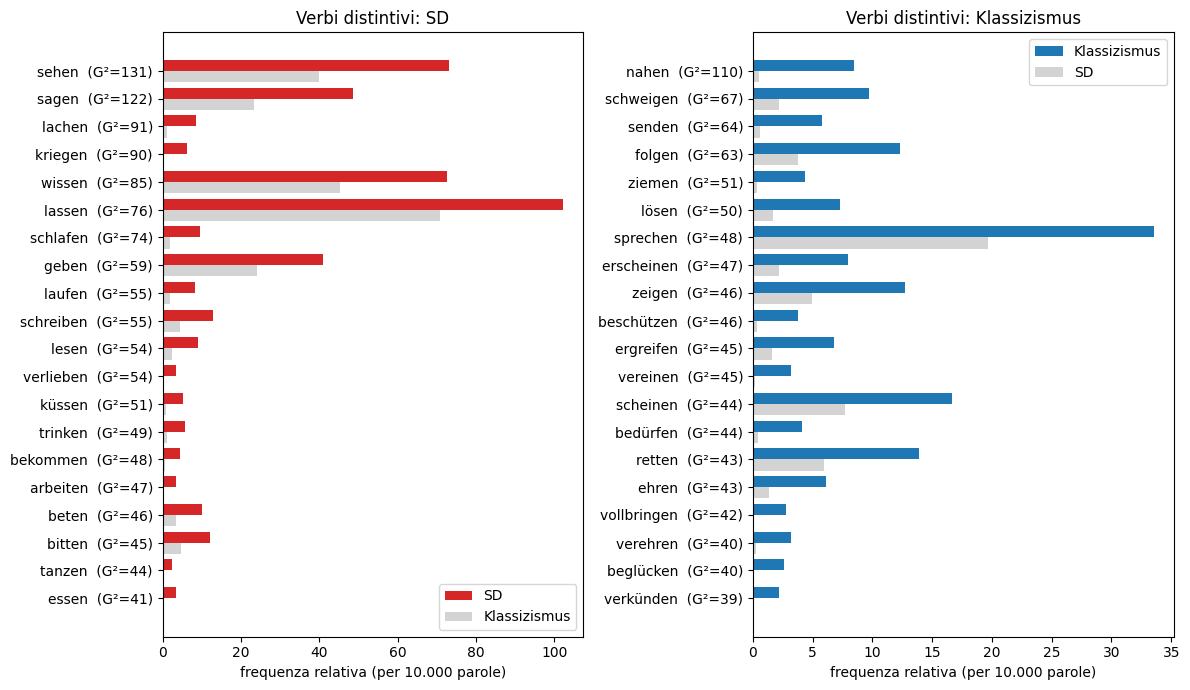

Salvato: /content/drive/MyDrive/risultati_frequenza/verbi_distintivi.csv


,classe,conteggio_SD,conteggio_Klassizismus,f_SD x10k,f_Klassizismus x10k,log2_ratio,G2,controlli superati (su 4),verdetto,quota_verbo,forme principali
sehen,SD,954,535,73.06,39.85,0.87,131.40,4,A robusta,0.87,"sehen (461), sieh (290), sieht (233), sehe (13..."
sagen,SD,636,312,48.71,23.24,1.07,122.15,4,A robusta,1.00,"sagen (700), sage (139), sagst (85), sagten (25)"
lachen,SD,113,14,8.65,1.04,3.01,90.68,4,A robusta,0.86,"lachen (82), lacht (26), lachte (11), lache (3..."
kriegen,SD,83,4,6.36,0.30,4.25,90.36,4,A robusta,0.98,"kriegen (36), kriegt (26), kriegte (8), gekrie..."
wissen,SD,949,609,72.68,45.36,0.68,84.51,3,C fragile,0.99,"weiß (889), wissen (444), wißt (78), wußte (49..."
...,...,...,...,...,...,...,...,...,...,...,...
beginnen,Klassizismus,9,50,0.69,3.72,-2.37,-30.27,3,,0.98,"beginnt (18), beginnen (12), begonnen (12), be..."
fassen,Klassizismus,102,201,7.81,14.97,-0.94,-30.27,4,,1.00,"fassen (107), faßt (83), gefaßt (63), fasse (2..."
schützen,Klassizismus,17,66,1.30,4.92,-1.89,-29.56,4,,0.86,"schützen (51), schützt (17), schütze (7), schü..."
siegen,Klassizismus,13,57,1.00,4.25,-2.05,-28.64,1,,1.00,"siegen (25), siegt (18), gesiegt (10), siegst ..."


In [33]:
# parametri di questa sezione
QUOTA_VERBO = 0.6    # un lemma conta come verbo se almeno il 60% delle sue occorrenze è taggato VERB
TOP_N_VERBI = 40     # quanti verbi distintivi mostrare per classe

# parte del discorso di ogni lemma (raccolta in 4a)
freq["pos_principale"] = [pos_del_lemma[w].most_common(1)[0][0] if w in pos_del_lemma else "" for w in freq.index]
freq["quota_verbo"] = [pos_del_lemma[w]["VERB"] / sum(pos_del_lemma[w].values()) if w in pos_del_lemma else 0.0
                       for w in freq.index]
e_verbo = freq["quota_verbo"] >= QUOTA_VERBO

n_verbi_testati = int((e_verbo.to_numpy() & da_testare).sum())
G2_BONF_VERBI = chi2.isf(0.05 / max(n_verbi_testati, 1), df=1)
print(f"{int(e_verbo.sum()):,} lemmi su {len(freq):,} sono verbi (quota VERB >= {QUOTA_VERBO:.0%}); "
      f"{n_verbi_testati:,} hanno almeno {MIN_COUNT} occorrenze")
print(f"Soglia G² di Bonferroni per i soli verbi: {G2_BONF_VERBI:.1f}  (per tutte le parole era {G2_BONF:.1f})\n")

def verbi_distintivi(classe, top_n=None):
    # i primi top_n verbi distintivi di una classe (ordinati per G²)
    top_n = TOP_N_VERBI if top_n is None else top_n
    segno = 1 if classe == "SD" else -1
    scelti = freq[e_verbo
                  & (freq[f"conteggio_{classe}"] >= MIN_COUNT)
                  & (freq[f"opere_{classe}"] >= MIN_OPERE)
                  & (segno * freq["log2_ratio"] >= MIN_LOG2)
                  & (segno * freq["G2"] > G2_BONF_VERBI)]
    return scelti.sort_values("G2", ascending=(classe != "SD")).head(top_n)

verbi_SD, verbi_K = verbi_distintivi("SD"), verbi_distintivi("Klassizismus")

CONTROLLI_RAPIDI = ["regge per opera", "concorda a pesi uguali", "concorda in ogni autore", "regge log-odds"]

def controlli_rapidi(tab, classe):
    # i quattro controlli rapidi (stessa logica delle sezioni 6b, 7a, 7b) per i verbi di una tabella
    segno = 1 if classe == "SD" else -1
    parole = list(tab.index)
    px = freq.index.get_indexer(parole)
    out = pd.DataFrame(index=parole)
    out["r_opere"] = per_opera["r_opere"].reindex(parole)
    out["q_opere"] = per_opera["q_opere"].reindex(parole)
    out["regge per opera"] = (out["q_opere"] < 0.05) & (segno * out["r_opere"] > 0)
    m_sd = frequenza_opera[opera_sd][:, px].mean(0)
    m_k = frequenza_opera[~opera_sd][:, px].mean(0)
    out["log2 pesi uguali"] = np.log2((m_sd + 0.1) / (m_k + 0.1))
    out["concorda a pesi uguali"] = segno * out["log2 pesi uguali"] >= MIN_LOG2
    ok_aut = np.ones(len(parole), dtype=bool)
    for aut in autori_condivisi:
        i_sd = [i for i, o in enumerate(opere) if autore_di[o] == aut and classe_di[o] == "SD"]
        i_k = [i for i, o in enumerate(opere) if autore_di[o] == aut and classe_di[o] == "Klassizismus"]
        cs, ck = X[i_sd].sum(0)[px], X[i_k].sum(0)[px]
        l2 = np.log2(((cs + 0.5) / X[i_sd].sum()) / ((ck + 0.5) / X[i_k].sum()))
        ok_aut &= (np.sign(l2) * segno > 0) | ((cs + ck) < MIN_OCC_AUTORE)
    out["concorda in ogni autore"] = ok_aut
    out["regge log-odds"] = (segno * tab["z_logodds"]) > Z_SOGLIA
    out["controlli superati (su 4)"] = out[CONTROLLI_RAPIDI].sum(axis=1)
    return out

def tabella_verbi(tab, classe):
    rapidi = controlli_rapidi(tab, classe)
    t = tab[["conteggio_SD", "conteggio_Klassizismus", "f_SD x10k", "f_Klassizismus x10k", "log2_ratio", "G2", "z_logodds",
             "opere_SD", "opere_Klassizismus", "quota_verbo"]].join(rapidi)
    t.insert(0, "classe", classe)
    t["verdetto"] = controlli["verdetto"].reindex(t.index).fillna("")        # solo per i verbi entro TOP_N
    t["forme principali"] = [", ".join(f"{f} ({n})" for f, n in forme_del_lemma[w].most_common(5)) for w in t.index]
    return t

tab_verbi = pd.concat([tabella_verbi(verbi_SD, "SD"), tabella_verbi(verbi_K, "Klassizismus")])

for c in classi:
    t = tab_verbi[tab_verbi["classe"] == c]
    solidi = t.index[t["controlli superati (su 4)"] == 4]
    print(f"{c}: {len(t)} verbi distintivi, {len(solidi)} superano tutti e 4 i controlli rapidi")
    print("   solidi:      ", ", ".join(solidi) or "nessuno")
    riserve = t[t["controlli superati (su 4)"] < 4]
    print("   con riserve: ", "; ".join(f"{w} (non: {', '.join(col for col in CONTROLLI_RAPIDI if not r[col])})"
                                       for w, r in riserve.iterrows()) or "nessuno", "\n")

ambigui = [w for w in candidate if 0.2 <= freq.loc[w, "quota_verbo"] < QUOTA_VERBO]
print("Parole distintive della sezione 6 che sono verbo solo in parte (omonimie verbo/nome o errori del tagger):")
print("  ", ", ".join(f"{w} ({freq.loc[w, 'quota_verbo']:.0%} verbo)" for w in ambigui) or "nessuna")

# grafico: i primi 20 verbi per classe
fig, assi = plt.subplots(1, 2, figsize=(12, 7))
for ax, (c, tab, colore) in zip(assi, [("SD", verbi_SD, "tab:red"), ("Klassizismus", verbi_K, "tab:blue")]):
    altra = "Klassizismus" if c == "SD" else "SD"
    top = tab.head(20)
    y = np.arange(len(top))[::-1]
    ax.barh(y + 0.2, top[f"f_{c} x10k"], height=0.4, color=colore, label=c)
    ax.barh(y - 0.2, top[f"f_{altra} x10k"], height=0.4, color="lightgray", label=altra)
    ax.set_yticks(y)
    ax.set_yticklabels([f"{w}  (G²={abs(g):.0f})" for w, g in zip(top.index, top["G2"])])
    ax.set_xlabel("frequenza relativa (per 10.000 parole)")
    ax.set_title(f"Verbi distintivi: {c}")
    ax.legend()
plt.tight_layout()
plt.show()

Path(CARTELLA_OUT).mkdir(parents=True, exist_ok=True)
tab_verbi.to_csv(Path(CARTELLA_OUT) / "verbi_distintivi.csv", encoding="utf-8-sig")
print("Salvato:", Path(CARTELLA_OUT) / "verbi_distintivi.csv")
tab_verbi[["classe", "conteggio_SD", "conteggio_Klassizismus", "f_SD x10k", "f_Klassizismus x10k", "log2_ratio", "G2",
           "controlli superati (su 4)", "verdetto", "quota_verbo", "forme principali"]].round(2)

In [34]:
# verbi modali: tolti dall'analisi principale (spaCy li tagga AUX), controllati qui a parte
# Qui si contano le forme direttamente nel testo; le frequenze sono per 10.000 parole del TESTO (non delle sole parole utili).
MODALI = {
    "können": ["kann", "kannst", "können", "könnt", "konnte", "konntest", "konnten", "könnte", "könntest", "könnten", "gekonnt"],
    "müssen": ["muss", "muß", "musst", "mußt", "müssen", "müsst", "müßt", "musste", "mußte", "musstest", "mußtest",
               "mussten", "mußten", "müsste", "müßte", "müssten", "müßten", "gemusst", "gemußt"],
    "sollen": ["soll", "sollst", "sollen", "sollt", "sollte", "solltest", "sollten", "gesollt"],
    "wollen": ["will", "willst", "wollen", "wollt", "wollte", "wolltest", "wollten", "gewollt"],
    "dürfen": ["darf", "darfst", "dürfen", "dürft", "durfte", "durftest", "durften", "dürfte", "dürftest", "dürften", "gedurft"],
    "mögen":  ["mag", "magst", "mögen", "mögt", "mochte", "mochtest", "mochten", "möchte", "möchtest", "möchten", "gemocht"],
}
forma_a_modale = {f: m for m, fs in MODALI.items() for f in fs}
cnt_modali = {o: Counter() for o in opere}
tot_testo = {o: 0 for o in opere}
for o in opere:
    for battuta in tei[o]["battute"]:
        for w in re.findall(r"[^\W\d_]+", sistema_elisioni(battuta)):
            tot_testo[o] += 1
            m = forma_a_modale.get(w.lower())
            if m:
                cnt_modali[o][m] += 1

n_testo = {c: sum(tot_testo[o] for o in opere if classe_di[o] == c) for c in classi}
righe_m = []
for m in MODALI:
    a_ = sum(cnt_modali[o][m] for o in opere if classe_di[o] == "SD")
    b_ = sum(cnt_modali[o][m] for o in opere if classe_di[o] == "Klassizismus")
    fo = np.array([cnt_modali[o][m] / tot_testo[o] * 1e4 for o in opere])
    U_m, p_m = mannwhitneyu(fo[opera_sd], fo[~opera_sd], alternative="two-sided")
    righe_m.append({"modale": m, "conteggio_SD": a_, "conteggio_Klassizismus": b_,
                    "f_SD x10k": a_ / n_testo["SD"] * 1e4, "f_Klassizismus x10k": b_ / n_testo["Klassizismus"] * 1e4,
                    "log2_ratio": np.log2(((a_ + 0.5) / n_testo["SD"]) / ((b_ + 0.5) / n_testo["Klassizismus"])),
                    "G2": float(g2(a_, b_, n_testo["SD"], n_testo["Klassizismus"])),
                    "r_opere": 2 * U_m / (opera_sd.sum() * (~opera_sd).sum()) - 1, "p_opere": p_m})
tab_modali = pd.DataFrame(righe_m).set_index("modale")
tab_modali["q_opere"] = multipletests(tab_modali["p_opere"], method="fdr_bh")[1]
print("Verbi modali (positivo = più frequente nello SD, negativo = nella Klassizismus). Con 6 verbi testati |G²| > 10,83 basta come soglia indicativa.")
tab_modali.to_csv(Path(CARTELLA_OUT) / "verbi_modali.csv", encoding="utf-8-sig")
tab_modali.round(3)

Verbi modali (positivo = più frequente nello SD, negativo = nella Klassizismus). Con 6 verbi testati |G²| > 10,83 basta come soglia indicativa.


,conteggio_SD,conteggio_Klassizismus,f_SD x10k,f_Klassizismus x10k,log2_ratio,G2,r_opere,p_opere,q_opere
modale,,,,,,,,,
können,2131,1479,55.691,42.289,0.397,67.059,0.580,0.002,0.004
müssen,1377,858,35.986,24.533,0.552,79.463,0.681,0.000,0.001
sollen,1863,1291,48.687,36.914,0.399,59.239,0.580,0.002,0.004
wollen,2987,1529,78.061,43.719,0.836,357.244,0.866,0.000,0.000
dürfen,238,344,6.220,9.836,-0.660,-30.125,-0.440,0.022,0.026
mögen,435,372,11.368,10.637,0.096,0.888,0.176,0.363,0.363


## 11c. Contesto di ogni parola distintiva

Per ogni parola (verbi compresi) questa sezione mostra:

- **forme**: quali forme del testo sono confluite nel lemma, separatamente per classe (es. *sieh, siehst* contro *sehet*), che dicono qualcosa su persona, tempo e imperativo;
- **vicini frequenti**: i lemmi che stanno più spesso nelle `FINESTRA_COLL` parole prima o dopo (3 + 3);
- **vicini specifici**: gli stessi lemmi, ma ordinati per quanto compaiono *più spesso di quanto farebbe il caso* (misura *local MI*: conteggio × log₂(osservato / atteso)). I vicini frequenti sono dominati da parole comuni (*kommen*, *sagen*), i vicini specifici mostrano le vere associazioni (*gnädig* + *Herr*);
- **frasi di esempio**: fino a `N_ESEMPI` per classe, prese a caso ma da **opere diverse** (così un'opera sola non domina), con la parola tra [parentesi quadre].

Tutto è mostrato **per entrambe le classi**, anche per una parola tipica dello SD: vedere come la stessa parola si comporta nella Klassizismus è spesso la parte più istruttiva (*Herr* in *Herr Gott* contro *gnädiger Herr*).

Nota: il testo mostrato ha la stessa normalizzazione dell'analisi (elisioni ricomposte, *th* → *t*, *ey* → *ei*); i nomi dei personaggi e le parole scartate (stopword, pronomi...) non compaiono tra i vicini. Per i vicini grezzi, comprese le parole grammaticali, resta `collocati` della sezione 4c.

`scheda("lemma")` stampa la scheda di una parola; `tabella_contesti(lista)` produce una tabella con una riga per parola, che viene salvata in CSV ed Excel.

In [35]:
FINESTRA_COLL = 3      # parole a sinistra e a destra considerate "vicine"
N_COLL        = 8      # quanti vicini mostrare per elenco
MIN_COLL      = 3      # un vicino deve comparire almeno tante volte
N_ESEMPI      = 3      # frasi di esempio per classe
LARGH_ESEMPIO = 70     # caratteri mostrati a sinistra e a destra della parola

# da ogni forma del testo al suo lemma
lemmi_validi = set(freq.index)
migliore = {}
for lemma, cnt in forme_del_lemma.items():
    if lemma not in lemmi_validi:
        continue
    for forma, n in cnt.items():
        if forma not in migliore or n > migliore[forma][1]:
            migliore[forma] = (lemma, n)
lemma_di_forma = {f: l for f, (l, n) in migliore.items()}

# testo con la stessa normalizzazione dell'analisi (elisioni e grafie sistemate)
RIGHE = []        # una riga per battuta: (opera, testo, [(parola minuscola, inizio, fine), ...])
for opera, dati in tei.items():
    if opera not in conteggi:          # i frammenti esclusi in 4a restano esclusi
        continue
    for battuta in dati["battute"]:
        t = re.sub(r"[^\W\d_]+", lambda m: normalizza_parola(m.group(0)), sistema_elisioni(battuta))
        toks = [(m.group(0).lower(), m.start(), m.end()) for m in re.finditer(r"[^\W\d_]+", t)]
        RIGHE.append((opera, t, toks))
parole_testo = {c: sum(len(toks) for o, t, toks in RIGHE if classe_di[o] == c) for c in classi}
print(f"{len(RIGHE):,} battute pronte; parole del testo: " + ", ".join(f"{c} {n:,}" for c, n in parole_testo.items()))

def scegli_esempi(voci, n, rng_e):
    # n occorrenze a caso, prima da opere diverse
    voci = list(voci)
    rng_e.shuffle(voci)
    scelti, viste = [], set()
    for voce in voci:
        if RIGHE[voce[0]][0] not in viste:
            scelti.append(voce)
            viste.add(RIGHE[voce[0]][0])
            if len(scelti) == n:
                return scelti
    for voce in voci:
        if voce not in scelti:
            scelti.append(voce)
            if len(scelti) == n:
                break
    return scelti

def formatta_esempio(voce):
    r, i = voce
    opera, t, toks = RIGHE[r]
    _, a, b = toks[i]
    riga = f"…{t[max(0, a - LARGH_ESEMPIO):a]}[{t[a:b]}]{t[b:b + LARGH_ESEMPIO]}…"
    return re.sub(r"\s+", " ", riga), opera

def contesti(lemmi, finestra=None, n_campioni=300, seme=0):
    # Una sola passata sul testo per tutti i lemmi richiesti. Ritorna {(lemma, classe): {...}}.
    finestra = FINESTRA_COLL if finestra is None else finestra
    rng_c = np.random.default_rng(seme)
    richiesti = [l for l in dict.fromkeys(lemmi) if l in forme_del_lemma and l in lemmi_validi]
    forma_a_lemmi = {}
    for l in richiesti:
        for f in forme_del_lemma[l]:
            forma_a_lemmi.setdefault(f, []).append(l)
    stato = {(l, c): {"n": 0, "forme": Counter(), "vicini": Counter(), "voci": [], "opere": set()}
             for l in richiesti for c in classi}
    for r, (opera, t, toks) in enumerate(RIGHE):
        c = classe_di[opera]
        parole = [w for w, _, _ in toks]
        for i, w in enumerate(parole):
            bersagli = forma_a_lemmi.get(w)
            if not bersagli:
                continue
            for l in bersagli:
                s = stato[(l, c)]
                s["n"] += 1
                s["forme"][w] += 1
                s["opere"].add(opera)
                for j in range(max(0, i - finestra), min(len(parole), i + finestra + 1)):
                    if j != i:
                        v = lemma_di_forma.get(parole[j])
                        if v is not None and v != l:
                            s["vicini"][v] += 1
                if len(s["voci"]) < n_campioni:               # campione casuale uniforme delle occorrenze
                    s["voci"].append((r, i))
                else:
                    k = int(rng_c.integers(0, s["n"]))
                    if k < n_campioni:
                        s["voci"][k] = (r, i)
    esito = {}
    for (l, c), s in stato.items():
        n = s["n"]
        specifici = []
        for v, o_ in s["vicini"].items():
            atteso = n * 2 * finestra * per_classe[c][v] / parole_testo[c]
            if o_ >= MIN_COLL and atteso > 0 and o_ > atteso:
                specifici.append((v, o_, o_ * np.log2(o_ / atteso)))
        specifici.sort(key=lambda x: -x[2])
        esito[(l, c)] = {
            "n": n, "opere": s["opere"], "forme": s["forme"],
            "frequenti": [(v, o_) for v, o_ in s["vicini"].most_common() if o_ >= MIN_COLL],
            "specifici": [(v, o_) for v, o_, _ in specifici],
            "esempi": [formatta_esempio(v) for v in scegli_esempi(s["voci"], N_ESEMPI, rng_c)],
        }
    return esito

def _elenco(coppie, n=N_COLL):
    return ", ".join(f"{v} ({k})" for v, k in coppie[:n]) or "-"

def scheda(lemma, ctx=None):
    # scheda di una parola: forme, vicini ed esempi, per SD e per Klassizismus
    if lemma not in lemmi_validi:
        print(f"'{lemma}' non è nel vocabolario")
        return
    ctx = ctx if ctx is not None else contesti([lemma])
    riga = freq.loc[lemma]
    tipo = riga.get("pos_principale", "")
    print("=" * 100)
    print(f"{lemma.upper()}  [{tipo}]   G² = {riga['G2']:+.1f}  ({'tipica SD' if riga['G2'] > 0 else 'tipica Klassizismus'})")
    for c in classi:
        s = ctx[(lemma, c)]
        print(f"\n  {c}: {s['n']} occorrenze in {len(s['opere'])} opere ({riga[f'f_{c} x10k']:.1f} per 10.000 parole)")
        print("    forme:            ", ", ".join(f"{f} ({k})" for f, k in s["forme"].most_common(6)) or "-")
        print("    vicini frequenti: ", _elenco(s["frequenti"]))
        print("    vicini specifici: ", _elenco(s["specifici"]))
        for testo, opera in s["esempi"]:
            print(f"      · [{opera[:24]}] {testo}")
    print()

def tabella_contesti(parole, ctx=None):
    # una riga per parola, con forme, vicini ed esempi per classe (da salvare o aprire in Excel)
    ctx = ctx if ctx is not None else contesti(parole)
    righe = []
    for w in dict.fromkeys(parole):
        if (w, "SD") not in ctx:
            continue
        r = {"lemma": w, "tipica di": "SD" if freq.loc[w, "G2"] > 0 else "Klassizismus",
             "pos": freq.loc[w].get("pos_principale", ""), "G2": freq.loc[w, "G2"], "log2_ratio": freq.loc[w, "log2_ratio"]}
        for c in classi:
            s = ctx[(w, c)]
            r[f"occorrenze {c}"] = s["n"]
            r[f"forme {c}"] = ", ".join(f"{f} ({k})" for f, k in s["forme"].most_common(6))
            r[f"vicini frequenti {c}"] = _elenco(s["frequenti"])
            r[f"vicini specifici {c}"] = _elenco(s["specifici"])
            for k in range(N_ESEMPI):
                r[f"esempio {k + 1} {c}"] = (f"[{s['esempi'][k][1][:24]}] {s['esempi'][k][0]}" if k < len(s["esempi"]) else "")
        righe.append(r)
    return pd.DataFrame(righe).set_index("lemma")

27,301 battute pronte; parole del testo: SD 382,649, Klassizismus 349,733


In [36]:
# schede di esempio: i primi tre verbi di ciascuna classe e un caso polisemico (herr)
da_mostrare = list(verbi_SD.index[:3]) + list(verbi_K.index[:3]) + ["herr"]
ctx_demo = contesti(da_mostrare)
for w in da_mostrare:
    scheda(w, ctx_demo)
# Per un'altra parola: scheda("nome_del_lemma")

SEHEN  [VERB]   G² = +131.4  (tipica SD)

  SD: 1277 occorrenze in 21 opere (73.1 per 10.000 parole)
    forme:             sehen (357), sehn (221), sieh (192), sieht (127), seht (126), gesehen (108)
    vicini frequenti:  lassen (35), auge (28), herr (20), vater (18), stehen (16), sollen (14), liebe (13), mann (12)
    vicini specifici:  auge (28), ihr (5), dein (6), sollen (14), blaß (7), aug (8), donna (6), eurer (4)
      · [goethe-goetz-von-berlich] …Ich bitte dich, verrat mich nicht. Ich will aufs nächste Dorf und [sehn], ob ich nit mit warmen Überschlägen meinem Übel abhelfen kann. Wo kom…
      · [klinger-das-leidende-wei] …[Sieh] mich nicht so an, ich möchte gleich weinen. Gütigster! wie verdien ic…
      · [klinger-sturm-und-drang] …Aber ich habe Hoffnung, daß sein Vater ihn nie mehr [sehen] soll. Habe Hoffnung, daß der junge Bushy durch Liederlichkeit seinen …

  Klassizismus: 839 occorrenze in 17 opere (39.9 per 10.000 parole)
    forme:             sehn (217), sieh (131), 

In [37]:
# tabella con il contesto di tutte le parole distintive (sezione 6 + verbi della 11b)
PAROLE_CONTESTO = list(dict.fromkeys(list(candidate) + list(verbi_SD.index) + list(verbi_K.index)))
# Per aggiungerne altre: PAROLE_CONTESTO += ["wetter", "pflicht"]

tab_contesti = tabella_contesti(PAROLE_CONTESTO)
tab_contesti.to_csv(Path(CARTELLA_OUT) / "contesti_parole_distintive.csv", encoding="utf-8-sig")
try:
    tab_contesti.to_excel(Path(CARTELLA_OUT) / "contesti_parole_distintive.xlsx")
except Exception as errore:
    print("Excel non salvato (resta il CSV):", errore)
print(f"{len(tab_contesti)} parole, salvate in {Path(CARTELLA_OUT)}/contesti_parole_distintive.csv (.xlsx)")
tab_contesti[["tipica di", "pos", "G2", "occorrenze SD", "occorrenze Klassizismus",
              "vicini specifici SD", "vicini specifici Klassizismus"]].round(1)

160 parole, salvate in /content/drive/MyDrive/risultati_frequenza/contesti_parole_distintive.csv (.xlsx)


,tipica di,pos,G2,occorrenze SD,occorrenze Klassizismus,vicini specifici SD,vicini specifici Klassizismus
lemma,,,,,,,
herr,SD,NOUN,412.7,1199,421,"gnädig (110), baron (26), vetter (36), assesso...","gnädig (18), landvogt (10), hochwürdger (5), e..."
kopf,SD,NOUN,168.5,244,42,"verrückt (7), kugel (8), voll (6), schlinge (3...","euerm (3), verlieren (3)"
teufel,SD,NOUN,161.8,289,43,"hol (18), holen (10), hölle (9), höll (3), ker...","hol (4), tod (4), arm (3)"
junge,SD,NOUN,147.9,217,33,"brav (11), herr (20), herrlich (7), leute (7),...",mann (3)
sehen,SD,VERB,131.4,1277,839,"auge (28), ihr (5), dein (6), sollen (14), bla...","auge (23), dein (9), hieh (6), aug (6), mutter..."
...,...,...,...,...,...,...,...
beginnen,Klassizismus,VERB,-30.3,11,66,-,"eh (4), sturm (3), kampf (3), neu (3), edel (3)"
fassen,Klassizismus,VERB,-30.3,116,219,"mut (6), geist (6), hand (6), halten (5), sehe...","entschluß (6), begierig (3), roh (3), mut (5),..."
schützen,Klassizismus,VERB,-29.6,19,80,liebe (3),"götter (4), eur (3), könig (3)"


## 12. Salvataggio

Le tabelle vengono salvate come file CSV in `CARTELLA_OUT` (si aprono con Excel). La più importante è `tabella_finale.csv`.

In [38]:
out = Path(CARTELLA_OUT)
out.mkdir(parents=True, exist_ok=True)

freq.sort_values("G2", ascending=False).to_csv(out / "frequenze_relative.csv")
distintive_SD[colonne].to_csv(out / "distintive_SD.csv")
distintive_K[colonne].to_csv(out / "distintive_Klassizismus.csv")
tabella_finale.to_csv(out / "tabella_finale.csv")
per_opera.to_csv(out / "test_per_opera.csv")
LOAO.to_csv(out / "leave_one_author_out.csv")
asse.to_csv(out / "posizione_drammi_asse_lessicale.csv")
pd.Series(RIPARA, name="forma_piena").to_csv(out / "lemmi_riparati.csv")
pd.Series(sorted(NOMI), name="nome_tolto").to_csv(out / "nomi_tolti.csv", index=False)
pd.DataFrame({"opere": casuali_opere, "autori": casuali_autori}).to_csv(out / "permutazioni_distribuzioni.csv", index=False)
if campo_di:
    pd.Series(campo_di, name="campo").sort_values().to_csv(out / "campi_semantici.csv")
    campi_tab.to_csv(out / "campi_semantici_pesi.csv")
print("Salvati in", out)

Salvati in /content/drive/MyDrive/risultati_frequenza
